АНАЛИЗ ДАТАСЕТА NETFLIX USER BEHAVIOR

 1. ЗАГРУЗКА ДАННЫХ
--------------------------------------------------
 Данные успешно загружены!
   Размер датасета: 50000 строк, 20 колонок

 1.5 СОЗДАНИЕ УМЕНЬШЕННОЙ ВЕРСИИ ДАТАСЕТА
--------------------------------------------------
 Создана уменьшенная версия датасета:
   Исходный размер: 50000 строк
   Новый размер: 10000 строк
   Сохранено 20.0% данных
 Файл сохранен как 'netflix_lite.csv'

 Информация о датасете (уменьшенная версия):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    10000 non-null  object 
 1   age                        10000 non-null  int64  
 2   gender                     10000 non-null  object 
 3   country                    10000 non-null  object 
 4   account_age_months         10000 non-null  int64  
 5   subscriptio

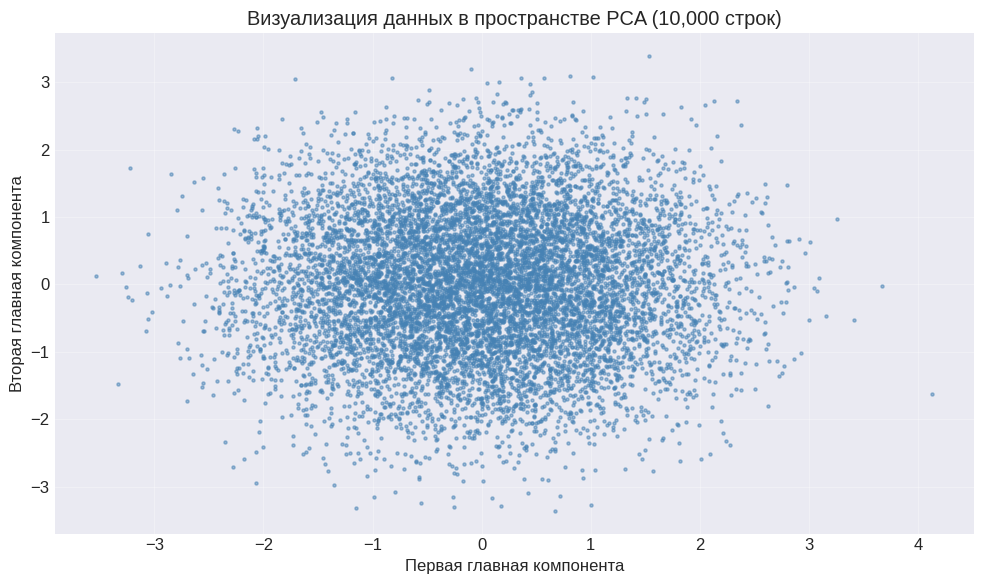


 Уменьшенная версия датасета создана и сохранена!
   Теперь можно продолжить анализ с 5 алгоритмами кластеризации


In [1]:
# Установка необходимых библиотек (если нужно)
# !pip install pandas numpy scikit-learn matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, Birch, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля для графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("="*70)
print("АНАЛИЗ ДАТАСЕТА NETFLIX USER BEHAVIOR")
print("="*70)

# ============================================
# 1. ЗАГРУЗКА И ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ
# ============================================
print("\n 1. ЗАГРУЗКА ДАННЫХ")
print("-"*50)

# Загрузка данных
try:
    df = pd.read_csv('netflix.csv')
    print(f" Данные успешно загружены!")
    print(f"   Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок")
except FileNotFoundError:
    print(" Файл не найден. Создаем демонстрационный датасет...")
    # Создаем синтетические данные на основе описания
    np.random.seed(42)
    n_samples = 50000  # Полный размер

    df = pd.DataFrame({
        'user_id': range(1, n_samples + 1),
        'age': np.random.randint(18, 70, n_samples),
        'gender': np.random.choice(['Male', 'Female', 'Other'], n_samples, p=[0.34, 0.33, 0.33]),
        'country': np.random.choice(['USA', 'Brazil', 'UK', 'India', 'Canada', 'Germany', 'France'], n_samples),
        'account_age_months': np.random.randint(1, 60, n_samples),
        'subscription_type': np.random.choice(['Basic', 'Standard', 'Premium'], n_samples, p=[0.3, 0.4, 0.3]),
        'monthly_fee': np.random.choice([7.99, 10.99, 13.99, 15.49, 19.99], n_samples),
        'payment_method': np.random.choice(['Credit Card', 'PayPal', 'Debit Card', 'Google Pay', 'Apple Pay'], n_samples),
        'primary_device': np.random.choice(['Smart TV', 'Laptop', 'Tablet', 'Smartphone', 'Desktop'], n_samples),
        'devices_used': np.random.randint(1, 6, n_samples),
        'favorite_genre': np.random.choice(['Drama', 'Comedy', 'Action', 'Documentary', 'Sci-Fi', 'Horror', 'Romance'], n_samples),
        'avg_watch_time_minutes': np.random.randint(15, 300, n_samples),
        'watch_sessions_per_week': np.random.randint(1, 25, n_samples),
        'binge_watch_sessions': np.random.randint(0, 25, n_samples),
        'completion_rate': np.random.uniform(0.2, 1.0, n_samples),
        'rating_given': np.random.uniform(1.0, 5.0, n_samples),
        'content_interactions': np.random.randint(0, 150, n_samples),
        'recommendation_click_rate': np.random.uniform(0.05, 0.95, n_samples),
        'days_since_last_login': np.random.randint(0, 90, n_samples),
        'churned': np.random.choice([0, 1], n_samples, p=[0.85, 0.15])
    })
    print(f" Создан демо-датасет с {n_samples} пользователями")

# ============================================
# 1.5 СОЗДАНИЕ УМЕНЬШЕННОЙ ВЕРСИИ ДАТАСЕТА
# ============================================
print("\n 1.5 СОЗДАНИЕ УМЕНЬШЕННОЙ ВЕРСИИ ДАТАСЕТА")
print("-"*50)

# Случайная выборка 10,000 строк
n_sample = 10000
df_lite = df.sample(n=n_sample, random_state=42).reset_index(drop=True)

print(f" Создана уменьшенная версия датасета:")
print(f"   Исходный размер: {df.shape[0]} строк")
print(f"   Новый размер: {df_lite.shape[0]} строк")
print(f"   Сохранено {df_lite.shape[0]/df.shape[0]*100:.1f}% данных")

# Сохраняем в новый CSV файл
df_lite.to_csv('netflix_lite.csv', index=False)
print(f" Файл сохранен как 'netflix_lite.csv'")

# Информация о данных
print("\n Информация о датасете (уменьшенная версия):")
print(df_lite.info(memory_usage='deep'))

print("\n Статистика числовых признаков:")
print(df_lite.describe().round(2))

print("\n Пропущенные значения:")
print(df_lite.isnull().sum()[df_lite.isnull().sum() > 0] if df_lite.isnull().sum().any() else "   Нет пропущенных значений")

# ============================================
# 2. ПРЕДОБРАБОТКА ДАННЫХ (на уменьшенной версии)
# ============================================
print("\n 2. ПРЕДОБРАБОТКА ДАННЫХ")
print("-"*50)

# Сохраняем целевую переменную для оценки
if 'gender' in df_lite.columns:
    true_labels = df_lite['gender'].map({'Male': 0, 'Female': 1, 'Other': 2}).fillna(2).astype(int).values
    print(f" Сохранена целевая переменная 'gender' (3 класса)")
    print(f"   Распределение: Male={sum(true_labels==0)}, Female={sum(true_labels==1)}, Other={sum(true_labels==2)}")
else:
    true_labels = None
    print(" Колонка 'gender' не найдена")

# Удаляем user_id
df_ml = df_lite.drop(columns=['user_id'], errors='ignore')
print(" Удалена колонка 'user_id'")

# Разделяем признаки на категориальные и числовые
categorical_cols = df_ml.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df_ml.select_dtypes(include=[np.number]).columns.tolist()

# Удаляем целевую переменную из признаков
if 'gender' in categorical_cols:
    categorical_cols.remove('gender')

print(f"\n Категориальные признаки ({len(categorical_cols)}): {categorical_cols}")
print(f" Числовые признаки ({len(numerical_cols)}): {numerical_cols}")

# Кодирование категориальных признаков
df_encoded = df_ml[numerical_cols].copy()  # Начинаем с числовых
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_ml[col].astype(str))
    label_encoders[col] = le
    print(f"    Закодирован признак: {col}")

# Масштабирование всех признаков
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_encoded),
    columns=df_encoded.columns,
    index=df_encoded.index
)

print(f"\n Итоговая матрица признаков: {df_scaled.shape}")
print(f"   Память: {df_scaled.memory_usage().sum() / 1024**2:.2f} MB")

# ============================================
# 3. УМЕНЬШЕНИЕ РАЗМЕРНОСТИ ДЛЯ ВИЗУАЛИЗАЦИИ
# ============================================
print("\n 3. УМЕНЬШЕНИЕ РАЗМЕРНОСТИ (PCA)")
print("-"*50)

pca = PCA(n_components=2, random_state=42)
df_pca = pca.fit_transform(df_scaled)

print(f"   Объясненная дисперсия первых двух компонент: {pca.explained_variance_ratio_.sum():.2%}")
print(f"   PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"   PC2: {pca.explained_variance_ratio_[1]:.2%}")

# Визуализация PCA
plt.figure(figsize=(10, 6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c='steelblue', alpha=0.5, s=5)
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Визуализация данных в пространстве PCA (10,000 строк)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Продолжение анализа с 5 алгоритмами кластеризации...
print("\n Уменьшенная версия датасета создана и сохранена!")
print("   Теперь можно продолжить анализ с 5 алгоритмами кластеризации")


 4. ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ПРИЗНАКОВ
--------------------------------------------------


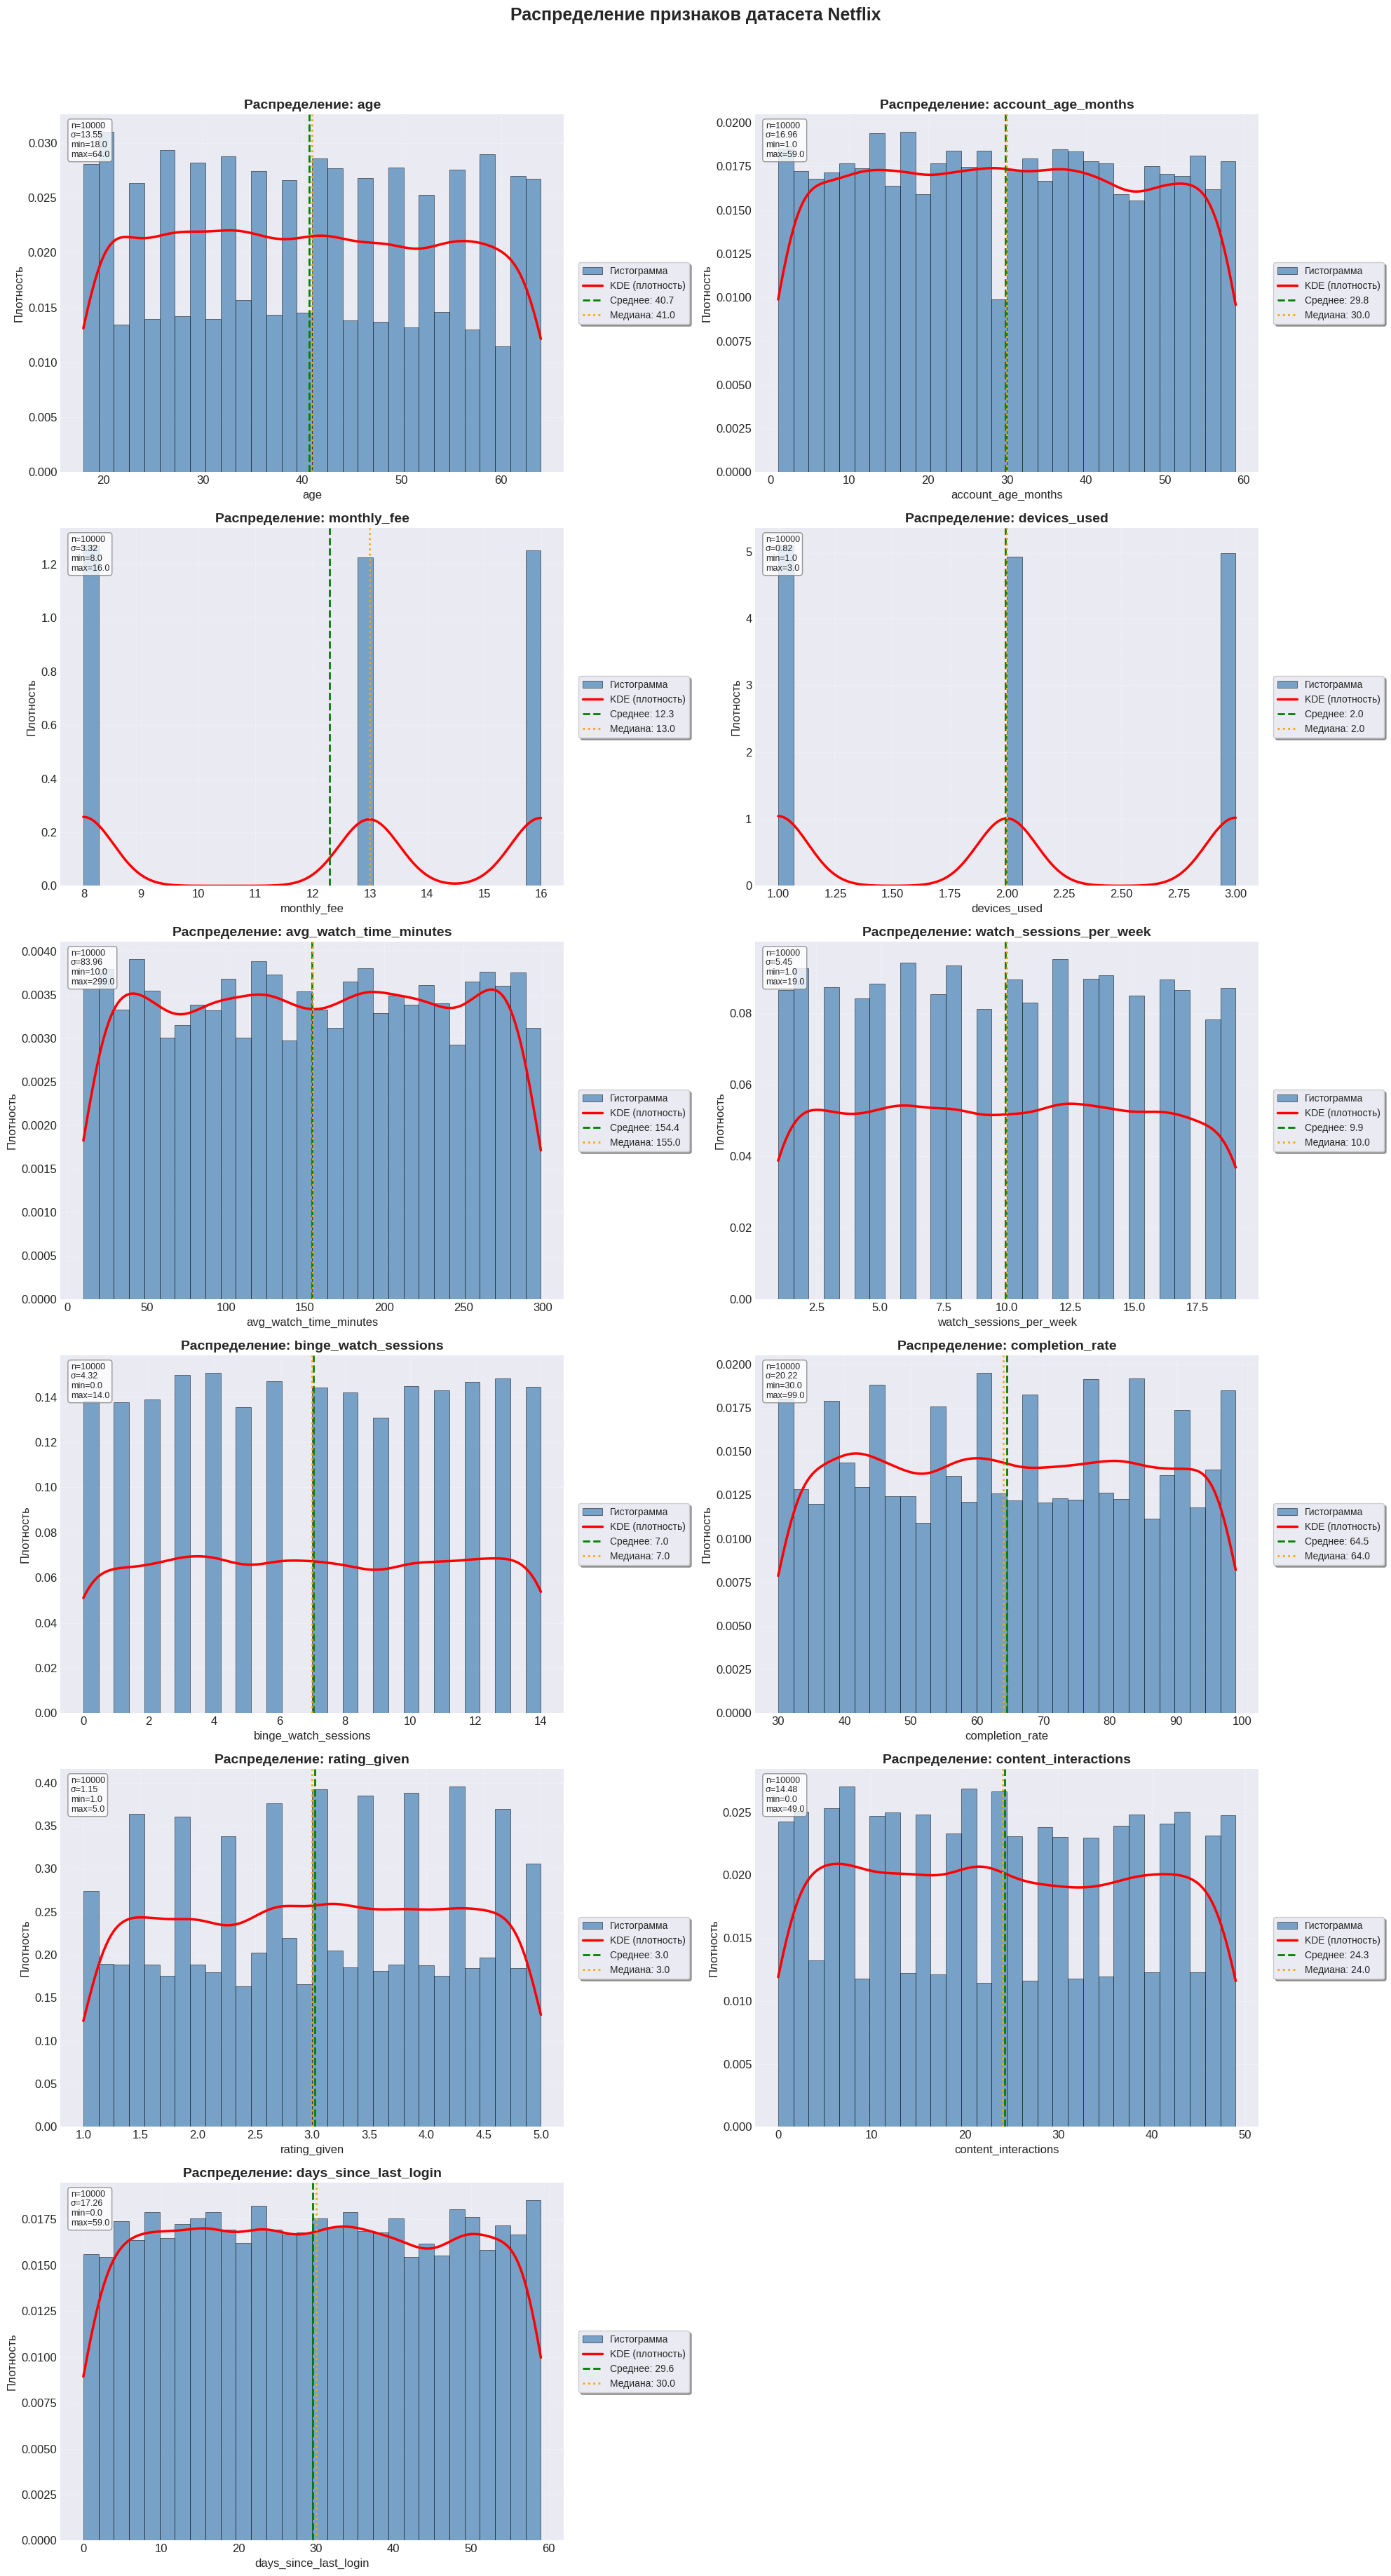


 4.1 ВИЗУАЛИЗАЦИЯ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
--------------------------------------------------


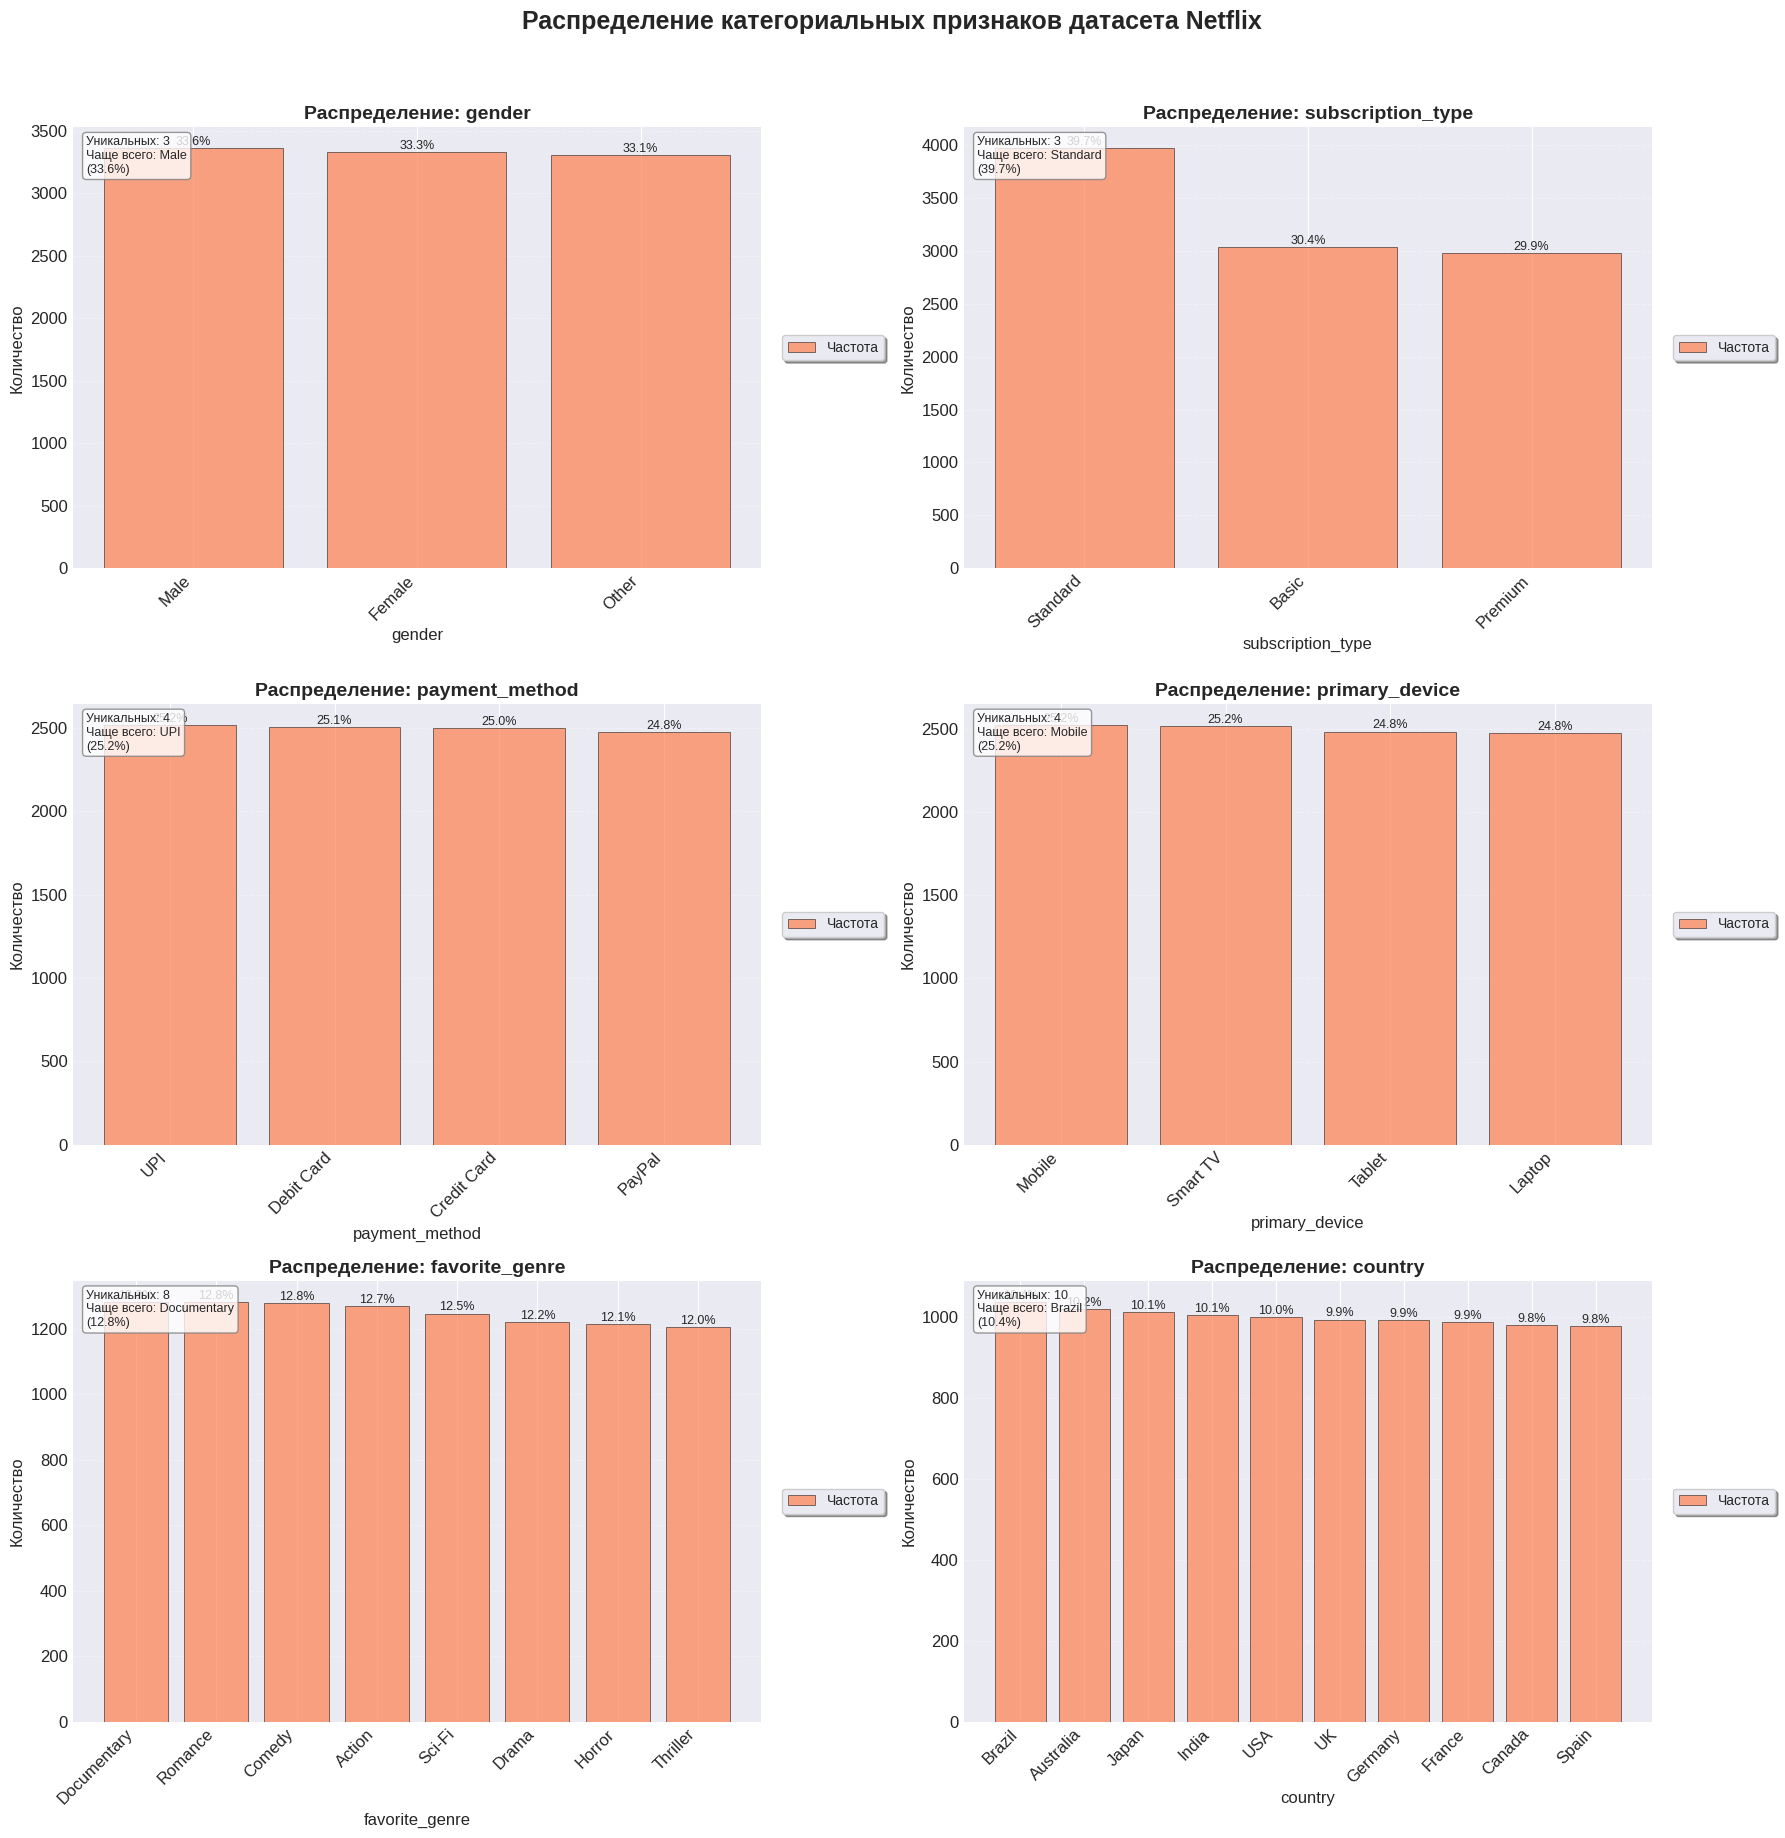


 4.2 ДЕТАЛЬНАЯ ВИЗУАЛИЗАЦИЯ ПОЛА И ВОЗРАСТА
--------------------------------------------------


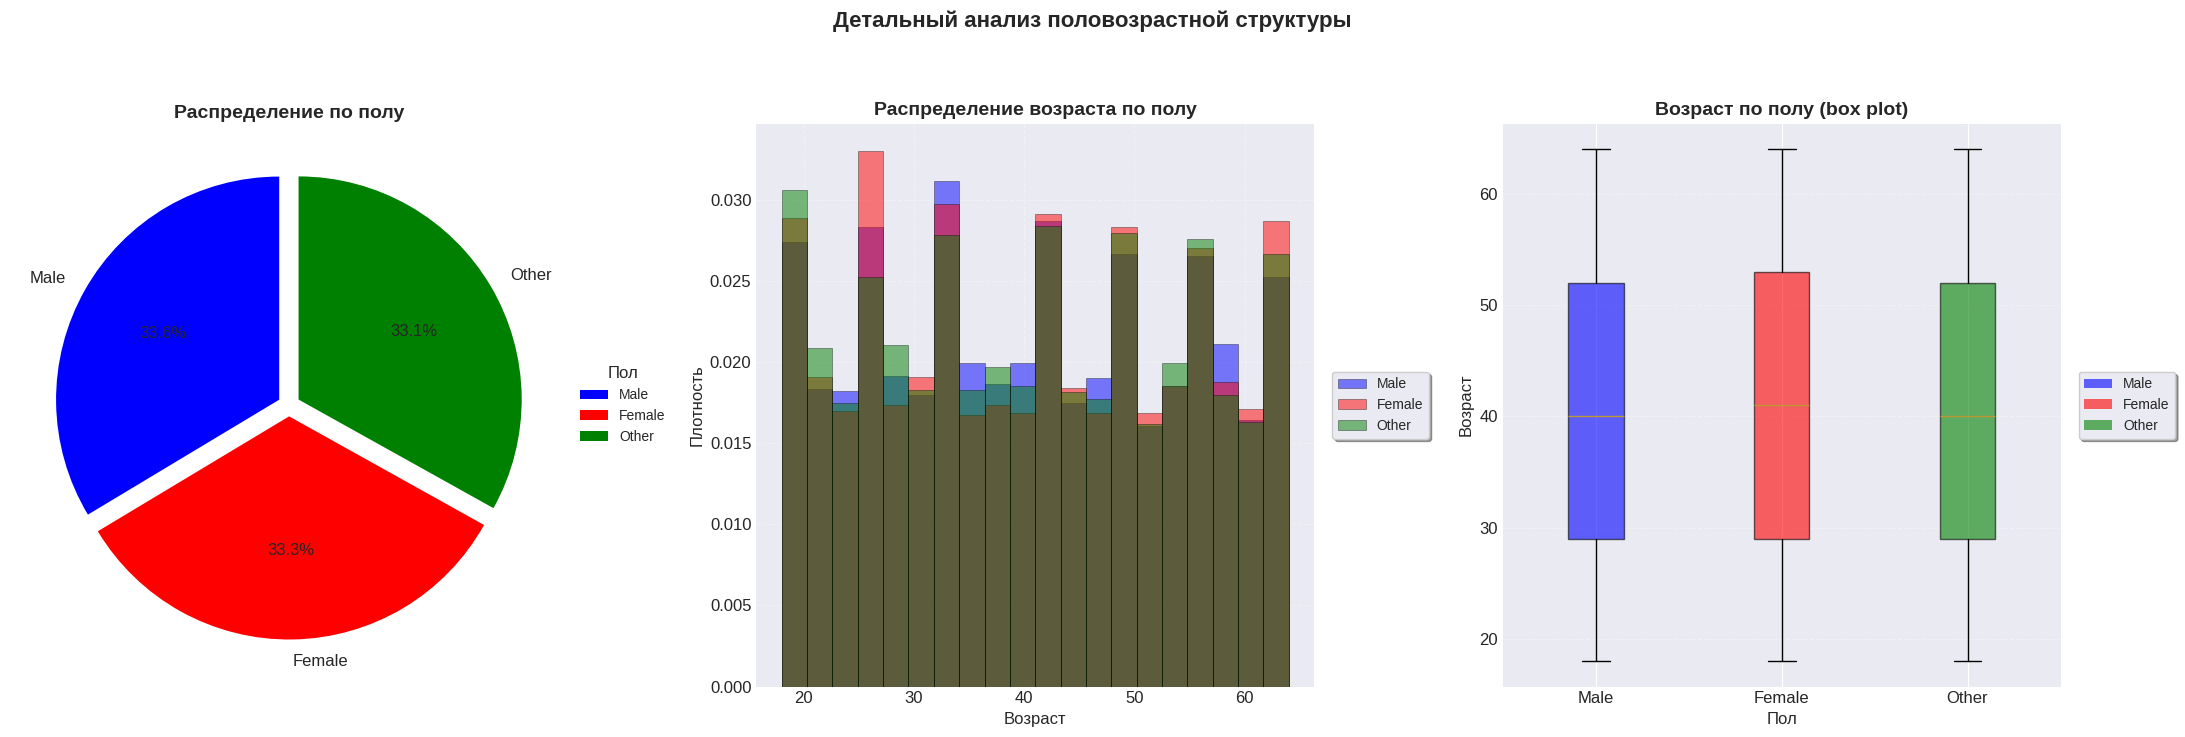


 МАТРИЦА КОРРЕЛЯЦИИ ЧИСЛОВЫХ ПРИЗНАКОВ
--------------------------------------------------


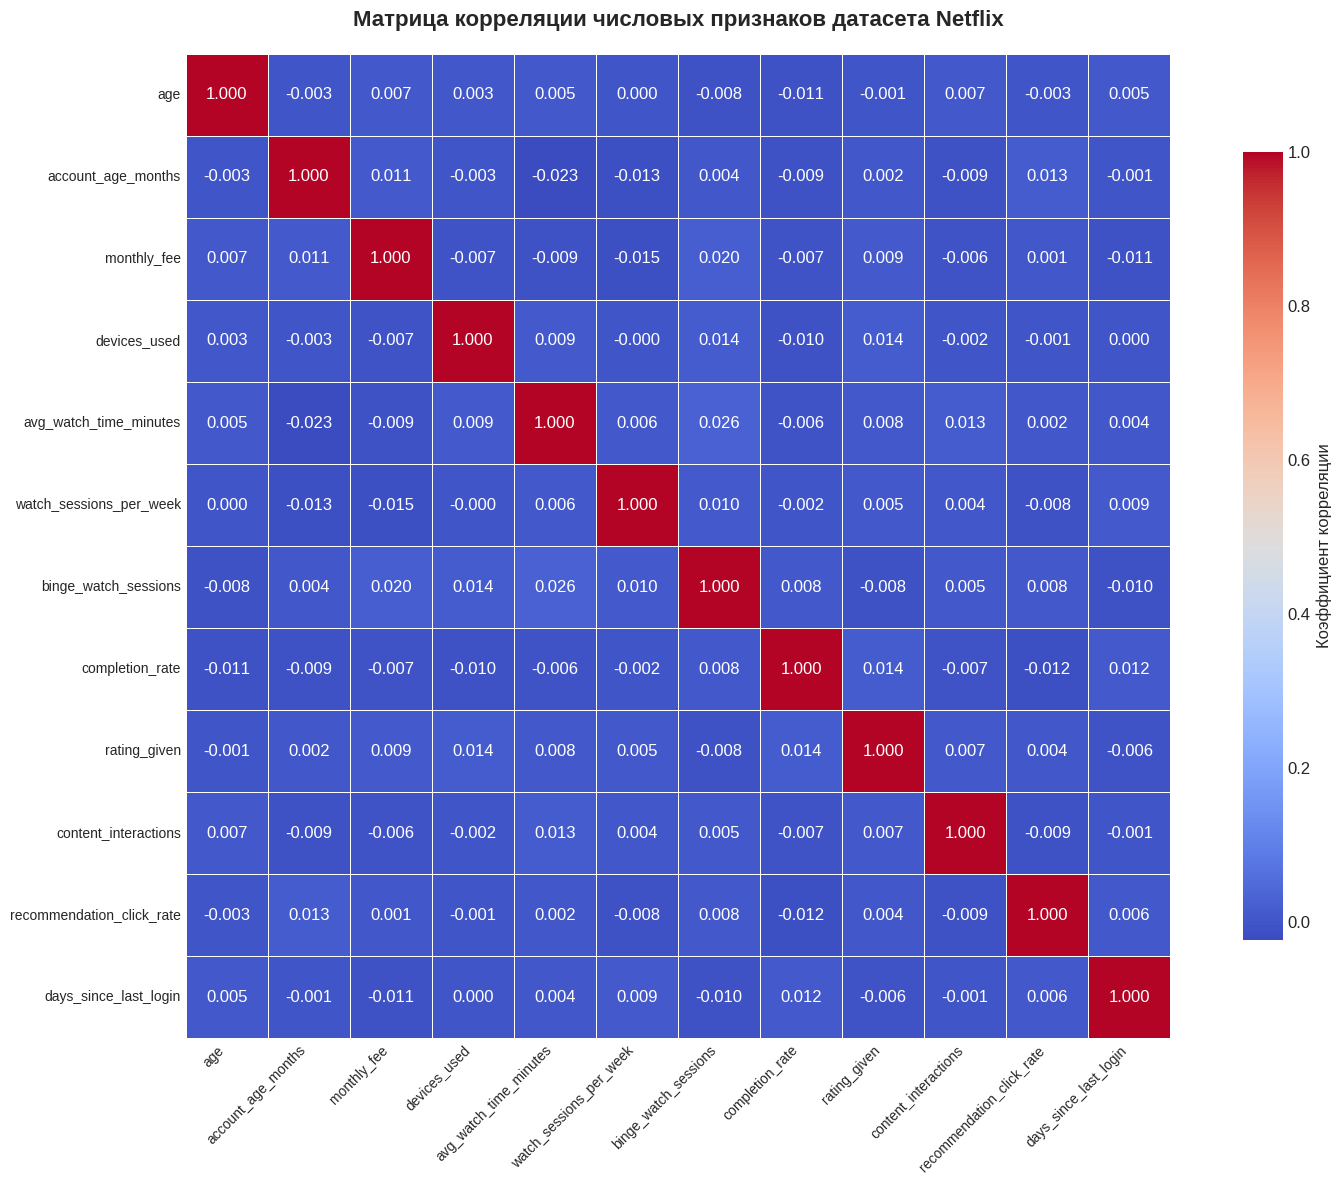


 Размер матрицы: 12 x 12 признаков
   Диапазон значений: от -0.023 до 1.000


In [2]:
# ============================================
# 4. ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ПРИЗНАКОВ ДАТАСЕТА
# ============================================
print("\n 4. ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ПРИЗНАКОВ")
print("-"*50)

# Выбираем ключевые признаки для визуализации
features_to_plot = ['age', 'account_age_months', 'monthly_fee', 'devices_used',
                   'avg_watch_time_minutes', 'watch_sessions_per_week',
                   'binge_watch_sessions', 'completion_rate', 'rating_given',
                   'content_interactions', 'days_since_last_login']

# Оставляем только существующие признаки
features_to_plot = [f for f in features_to_plot if f in df_lite.columns]

# Расчет количества строк и колонок для сетки графиков
n_features = len(features_to_plot)
n_cols = 2  # Уменьшаем количество колонок, чтобы освободить место для легенд
n_rows = (n_features + n_cols - 1) // n_cols

# Создаем фигуру с сеткой графиков
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 6))
axes = axes.flatten()

# Для каждого признака строим гистограмму с наложением кривой распределения
for idx, feature in enumerate(features_to_plot):
    ax = axes[idx]

    # Данные признака
    data = df_lite[feature].dropna()

    # Гистограмма
    n, bins, patches = ax.hist(data, bins=30, density=True,
                               alpha=0.7, color='steelblue',
                               edgecolor='black', linewidth=0.5,
                               label='Гистограмма')

    # Наложение кривой распределения (KDE - ядерная оценка плотности)
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    kde_values = kde(x_range)

    ax.plot(x_range, kde_values, 'r-', linewidth=2.5, label='KDE (плотность)')

    # Добавляем вертикальные линии для среднего и медианы
    mean_val = data.mean()
    median_val = data.median()

    ax.axvline(mean_val, color='green', linestyle='--', linewidth=2,
               label=f'Среднее: {mean_val:.1f}')
    ax.axvline(median_val, color='orange', linestyle=':', linewidth=2,
               label=f'Медиана: {median_val:.1f}')

    # Оформление
    ax.set_title(f'Распределение: {feature}', fontsize=14, fontweight='bold')
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Плотность', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')

    # Легенда справа от графика
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
             fontsize=10, frameon=True, fancybox=True, shadow=True)

    # Добавляем статистику слева вверху
    stats_text = f"""n={len(data)}
σ={data.std():.2f}
min={data.min():.1f}
max={data.max():.1f}"""
    ax.text(0.02, 0.98, stats_text,
            transform=ax.transAxes,
            ha='left', va='top',
            fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

# Скрываем лишние графики
for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Распределение признаков датасета Netflix', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================
# 4.1 ВИЗУАЛИЗАЦИЯ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
# ============================================
print("\n 4.1 ВИЗУАЛИЗАЦИЯ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("-"*50)

# Выбираем категориальные признаки
categorical_to_plot = ['gender', 'subscription_type', 'payment_method',
                       'primary_device', 'favorite_genre', 'country']

# Оставляем только существующие признаки
categorical_to_plot = [f for f in categorical_to_plot if f in df_lite.columns]

# Расчет количества строк и колонок для сетки графиков
n_cat_features = len(categorical_to_plot)
n_cat_cols = 2
n_cat_rows = (n_cat_features + n_cat_cols - 1) // n_cat_cols

# Создаем фигуру для категориальных признаков
fig, axes = plt.subplots(n_cat_rows, n_cat_cols, figsize=(18, n_cat_rows * 6))
axes = axes.flatten()

# Для каждого категориального признака строим столбчатую диаграмму
for idx, feature in enumerate(categorical_to_plot):
    ax = axes[idx]

    # Подсчет частот
    value_counts = df_lite[feature].value_counts()
    percentages = df_lite[feature].value_counts(normalize=True) * 100

    # Столбчатая диаграмма
    bars = ax.bar(range(len(value_counts)), value_counts.values,
                  color='coral', alpha=0.7, edgecolor='black', linewidth=0.5,
                  label='Частота')

    # Добавляем проценты на столбцы
    for i, (bar, pct) in enumerate(zip(bars, percentages.values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

    # Оформление
    ax.set_title(f'Распределение: {feature}', fontsize=14, fontweight='bold')
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Количество', fontsize=12)
    ax.set_xticks(range(len(value_counts)))
    ax.set_xticklabels(value_counts.index, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')

    # Легенда справа
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
             fontsize=10, frameon=True, fancybox=True, shadow=True)

    # Добавляем статистику слева
    unique_count = len(value_counts)
    most_common = value_counts.index[0]
    most_common_pct = percentages.values[0]
    stats_text = f"Уникальных: {unique_count}\nЧаще всего: {most_common}\n({most_common_pct:.1f}%)"
    ax.text(0.02, 0.98, stats_text,
            transform=ax.transAxes,
            ha='left', va='top',
            fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

# Скрываем лишние графики
for idx in range(n_cat_features, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Распределение категориальных признаков датасета Netflix',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================
# 4.2 ДЕТАЛЬНАЯ ВИЗУАЛИЗАЦИЯ ПОЛОВОЗРАСТНОЙ СТРУКТУРЫ
# ============================================
print("\n 4.2 ДЕТАЛЬНАЯ ВИЗУАЛИЗАЦИЯ ПОЛА И ВОЗРАСТА")
print("-"*50)

if 'gender' in df_lite.columns and 'age' in df_lite.columns:
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))

    # 1. Круговая диаграмма пола
    ax1 = axes[0]
    gender_counts = df_lite['gender'].value_counts()
    colors = {'Male': 'blue', 'Female': 'red', 'Other': 'green'}
    gender_colors = [colors.get(g, 'gray') for g in gender_counts.index]

    wedges, texts, autotexts = ax1.pie(gender_counts.values,
                                        labels=gender_counts.index,
                                        colors=gender_colors,
                                        autopct='%1.1f%%',
                                        startangle=90,
                                        explode=[0.05] * len(gender_counts))
    ax1.set_title('Распределение по полу', fontsize=14, fontweight='bold')

    # Легенда для круговой диаграммы
    ax1.legend(wedges, gender_counts.index,
              title="Пол",
              loc="center left",
              bbox_to_anchor=(1, 0, 0.5, 1),
              fontsize=10)

    # 2. Гистограмма возраста с разбивкой по полу
    ax2 = axes[1]
    for gender in gender_counts.index:
        gender_data = df_lite[df_lite['gender'] == gender]['age']
        ax2.hist(gender_data, bins=20, alpha=0.5,
                label=gender, density=True,
                color=colors.get(gender, 'gray'),
                edgecolor='black', linewidth=0.5)

    ax2.set_title('Распределение возраста по полу', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Возраст', fontsize=12)
    ax2.set_ylabel('Плотность', fontsize=12)
    ax2.grid(True, alpha=0.3, linestyle='--')

    # Легенда справа для гистограммы
    ax2.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
              fontsize=10, frameon=True, fancybox=True, shadow=True)

    # 3. Ящик с усами (box plot) возраста по полу
    ax3 = axes[2]
    data_to_plot = [df_lite[df_lite['gender'] == gender]['age'] for gender in gender_counts.index]
    bp = ax3.boxplot(data_to_plot, labels=gender_counts.index, patch_artist=True)

    # Раскрашиваем ящики
    for i, box in enumerate(bp['boxes']):
        box.set_facecolor(list(colors.values())[i % len(colors)])
        box.set_alpha(0.6)

    ax3.set_title('Возраст по полу (box plot)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Пол', fontsize=12)
    ax3.set_ylabel('Возраст', fontsize=12)
    ax3.grid(True, alpha=0.3, axis='y', linestyle='--')

    # Легенда для box plot
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors.get(g, 'gray'), alpha=0.6, label=g)
                      for g in gender_counts.index]
    ax3.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5),
              fontsize=10, frameon=True, fancybox=True, shadow=True)

    plt.suptitle('Детальный анализ половозрастной структуры', fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# ============================================
# МАТРИЦА КОРРЕЛЯЦИИ ДЛЯ ДАТАСЕТА
# ============================================
print("\n МАТРИЦА КОРРЕЛЯЦИИ ЧИСЛОВЫХ ПРИЗНАКОВ")
print("-"*50)

# Выбираем только числовые признаки из датасета (исключаем user_id если есть)
numerical_df = df_lite.select_dtypes(include=[np.number])
if 'user_id' in numerical_df.columns:
    numerical_df = numerical_df.drop(columns=['user_id'])

# Вычисляем матрицу корреляции
correlation_matrix = numerical_df.corr()

# Создаем фигуру с адаптивным размером
plt.figure(figsize=(16, 12))

# Строим тепловую карту
sns.heatmap(correlation_matrix,
            annot=True,  # Показываем значения
            fmt='.3f',   # Формат чисел (3 знака после запятой)
            cmap='coolwarm',  # Цветовая схема
            linewidths=0.5,   # Толщина линий
            square=True,      # Квадратные ячейки
            cbar_kws={'label': 'Коэффициент корреляции', 'shrink': 0.8})  # Подпись цветовой шкалы

# Настройка заголовка
plt.title('Матрица корреляции числовых признаков датасета Netflix',
          fontsize=16, fontweight='bold', pad=20)

# Поворачиваем подписи для лучшей читаемости
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

# Выводим основную статистику
print(f"\n Размер матрицы: {correlation_matrix.shape[0]} x {correlation_matrix.shape[1]} признаков")
print(f"   Диапазон значений: от {correlation_matrix.min().min():.3f} до {correlation_matrix.max().max():.3f}")



 4. ПОИСК ОПТИМАЛЬНОГО K
--------------------------------------------------
   Вычисление Gap-статистики...


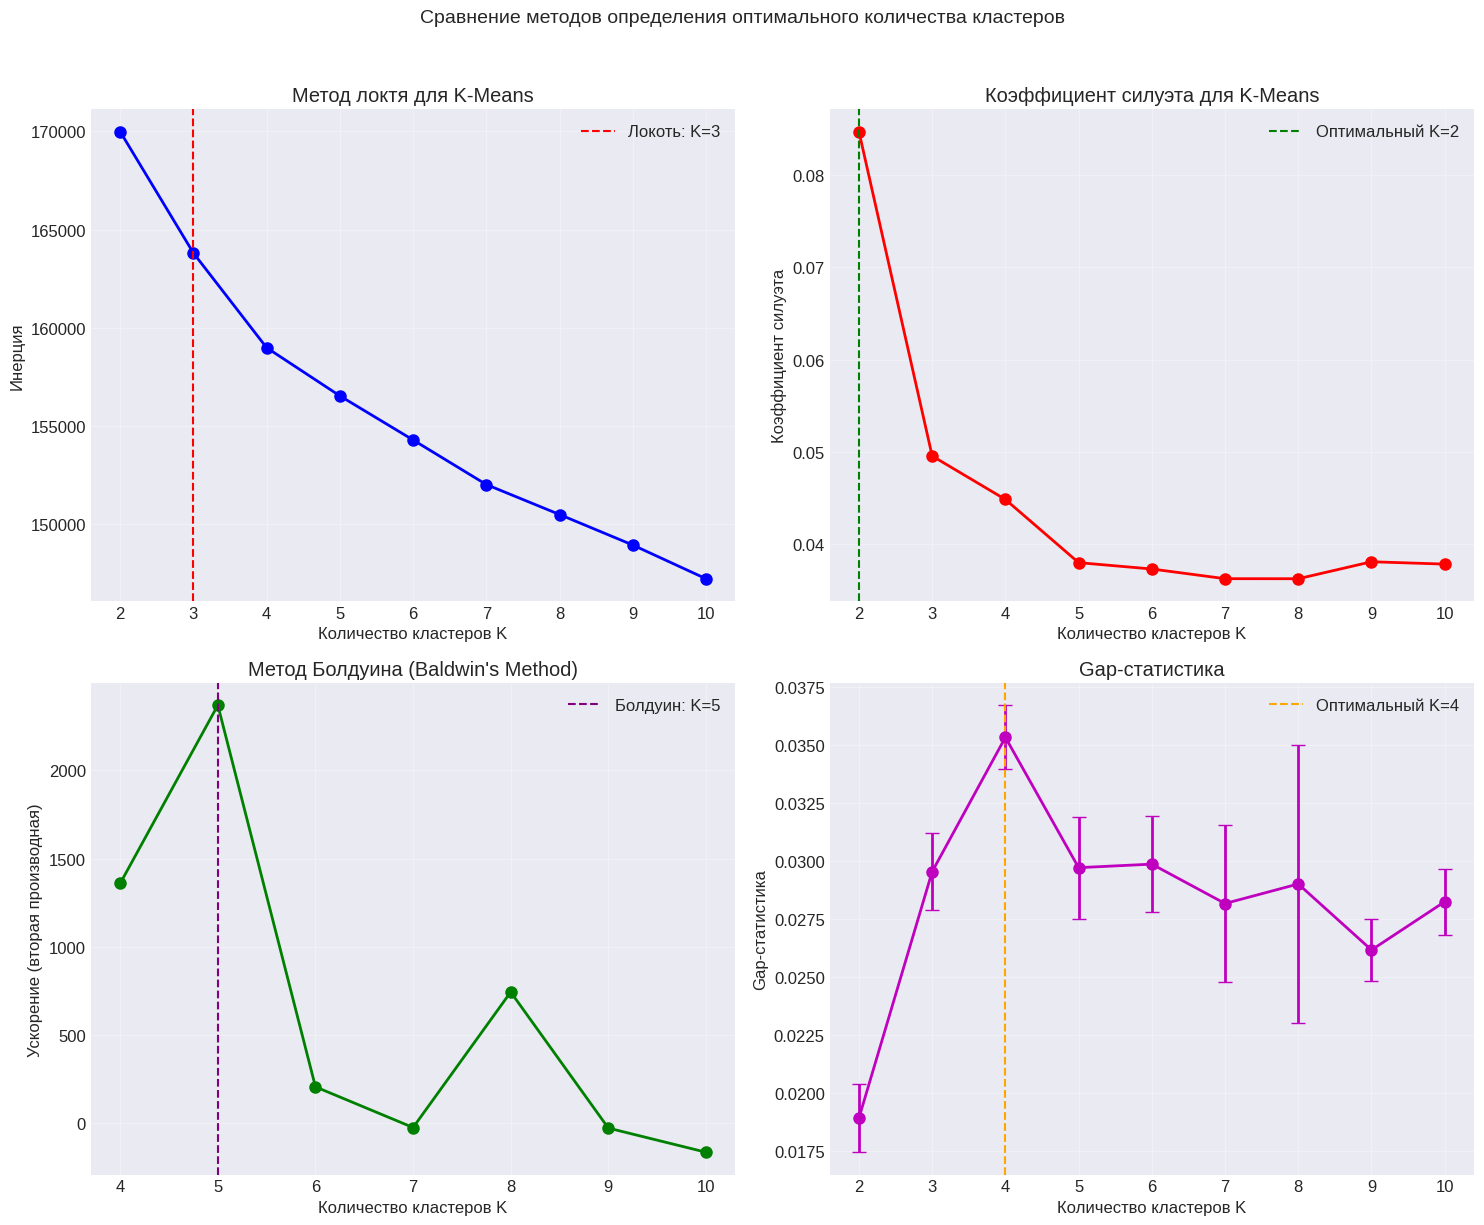


 РЕЗУЛЬТАТЫ ВСЕХ МЕТОДОВ:
--------------------------------------------------
   Метод локтя: K = 3
   Коэффициент силуэта: K = 2 (макс. силуэт = 0.085)
   Метод Болдуина: K = 5
   Gap-статистика: K = 4

 Консенсусное оптимальное K: 3 (на основе голосования 4 методов)

 Визуализация сравнения всех методов...


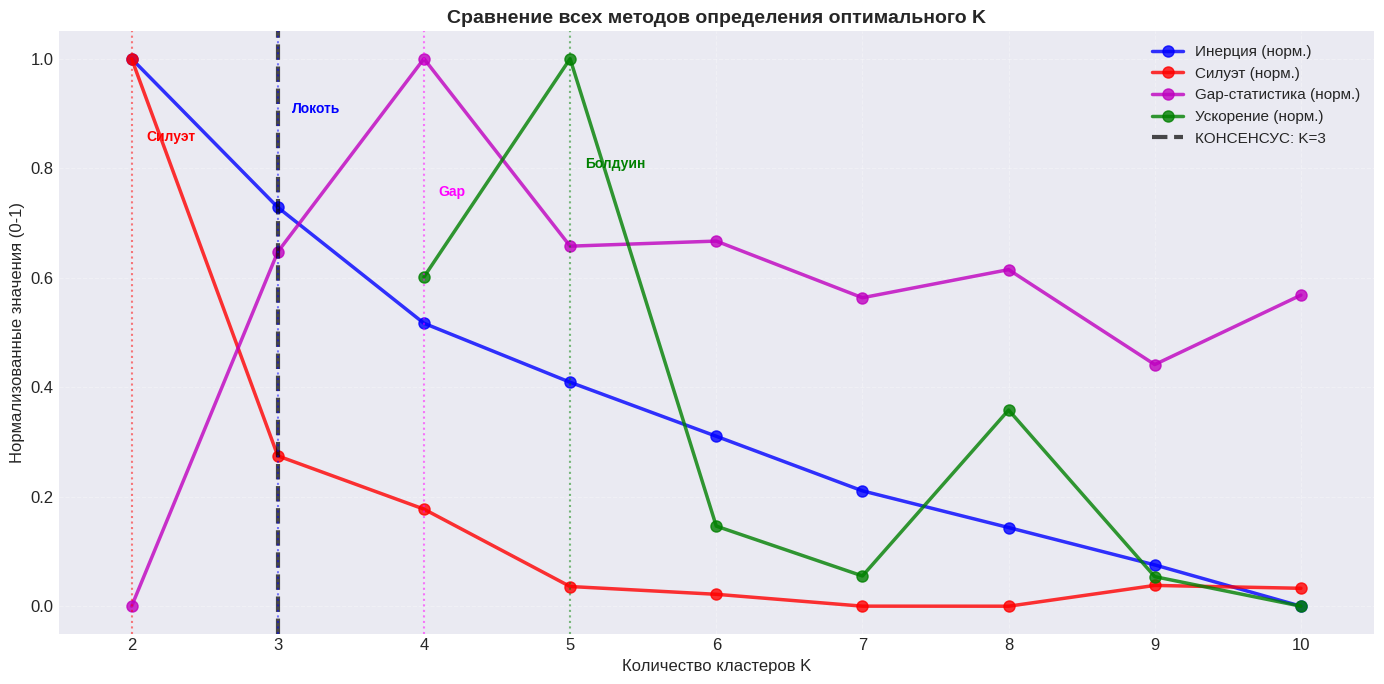


 Матрица голосования методов:
 K  Локоть  Силуэт  Болдуин  Gap  Всего голосов
 2       0       1        0    0              1
 3       1       0        0    0              1
 4       0       0        0    1              1
 5       0       0        1    0              1
 6       0       0        0    0              0
 7       0       0        0    0              0
 8       0       0        0    0              0
 9       0       0        0    0              0
10       0       0        0    0              0


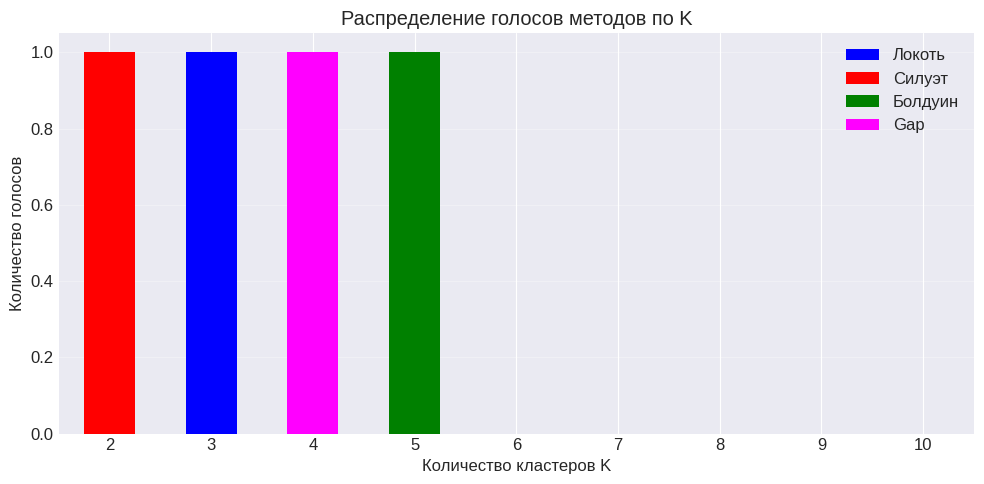


 Для дальнейшего анализа используем K = 3


In [3]:
# ============================================
#  ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО КОЛИЧЕСТВА КЛАСТЕРОВ
# ============================================
print("\n 4. ПОИСК ОПТИМАЛЬНОГО K")
print("-"*50)

# Метод локтя и силуэта для K-Means
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(df_scaled, labels))

# Метод Болдуина (Baldwin's method) - основан на производной инерции
# Вычисляем ускорение (вторую производную) для определения точки перегиба
inertia_diff = np.diff(inertias)  # первая производная
inertia_accel = np.diff(inertia_diff)  # вторая производная

# Добавляем NaN для выравнивания длины
inertia_accel = np.concatenate([[np.nan, np.nan], inertia_accel])

# Метод Gap-статистики
def compute_gap_statistic(X, k_range, n_references=5, random_state=42):
    """
    Вычисление Gap-статистики для определения оптимального k
    """
    np.random.seed(random_state)
    gaps = []
    gap_std = []

    # Общая дисперсия данных для генерации случайных данных
    X_std = X.std(axis=0)
    X_mean = X.mean(axis=0)

    for k in k_range:
        # Кластеризация реальных данных
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=5)
        kmeans.fit(X)
        real_inertia = np.log(kmeans.inertia_)

        # Генерация случайных данных и кластеризация
        ref_inertias = []
        for _ in range(n_references):
            # Случайные данные с таким же распределением
            X_ref = np.random.normal(loc=X_mean, scale=X_std, size=X.shape)
            kmeans_ref = KMeans(n_clusters=k, random_state=random_state, n_init=5)
            kmeans_ref.fit(X_ref)
            ref_inertias.append(np.log(kmeans_ref.inertia_))

        # Gap = среднее логов случайных данных - лог реальных
        gap = np.mean(ref_inertias) - real_inertia
        gaps.append(gap)

        # Стандартное отклонение
        gap_std.append(np.std(ref_inertias) * np.sqrt(1 + 1/n_references))

    return np.array(gaps), np.array(gap_std)

# Вычисляем Gap-статистику
print("   Вычисление Gap-статистики...")
gaps, gap_std = compute_gap_statistic(df_scaled.values, K_range, n_references=5)

# Находим оптимальное k по Gap-статистике
# Оптимальное k - первое, где gap(k) >= gap(k+1) - gap_std(k+1)
optimal_k_gap = K_range[0]
for i in range(len(K_range)-1):
    if gaps[i] >= gaps[i+1] - gap_std[i+1]:
        optimal_k_gap = K_range[i]
        break
    else:
        optimal_k_gap = K_range[i+1]

# Визуализация всех методов
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Метод локтя
ax1 = axes[0, 0]
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Количество кластеров K')
ax1.set_ylabel('Инерция')
ax1.set_title('Метод локтя для K-Means')
ax1.grid(True, alpha=0.3)
# Находим точку перегиба методом "локтя"
elbow_point = K_range[np.argmin(np.diff(inertias)) + 1]
ax1.axvline(x=elbow_point, color='red', linestyle='--', label=f'Локоть: K={elbow_point}')
ax1.legend()

# 2. Коэффициент силуэта
ax2 = axes[0, 1]
ax2.plot(K_range, silhouettes, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Количество кластеров K')
ax2.set_ylabel('Коэффициент силуэта')
ax2.set_title('Коэффициент силуэта для K-Means')
ax2.grid(True, alpha=0.3)
best_k_silhouette = K_range[np.argmax(silhouettes)]
ax2.axvline(x=best_k_silhouette, color='green', linestyle='--', label=f'Оптимальный K={best_k_silhouette}')
ax2.legend()

# 3. Метод Болдуина (Baldwin) - ускорение инерции
ax3 = axes[1, 0]
ax3.plot(K_range, inertia_accel, 'go-', linewidth=2, markersize=8)
ax3.set_xlabel('Количество кластеров K')
ax3.set_ylabel('Ускорение (вторая производная)')
ax3.set_title('Метод Болдуина (Baldwin\'s Method)')
ax3.grid(True, alpha=0.3)
# Находим точку максимального ускорения
if not np.all(np.isnan(inertia_accel)):
    baldwin_point = K_range[np.nanargmax(inertia_accel)]
    ax3.axvline(x=baldwin_point, color='purple', linestyle='--', label=f'Болдуин: K={baldwin_point}')
    ax3.legend()

# 4. Gap-статистика
ax4 = axes[1, 1]
ax4.errorbar(K_range, gaps, yerr=gap_std, fmt='mo-', linewidth=2, markersize=8, capsize=5)
ax4.set_xlabel('Количество кластеров K')
ax4.set_ylabel('Gap-статистика')
ax4.set_title('Gap-статистика')
ax4.grid(True, alpha=0.3)
ax4.axvline(x=optimal_k_gap, color='orange', linestyle='--', label=f'Оптимальный K={optimal_k_gap}')
ax4.legend()

plt.suptitle('Сравнение методов определения оптимального количества кластеров', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Вывод результатов всех методов
print("\n РЕЗУЛЬТАТЫ ВСЕХ МЕТОДОВ:")
print("-"*50)
print(f"   Метод локтя: K = {elbow_point}")
print(f"   Коэффициент силуэта: K = {best_k_silhouette} (макс. силуэт = {max(silhouettes):.3f})")
if not np.all(np.isnan(inertia_accel)):
    print(f"   Метод Болдуина: K = {baldwin_point}")
print(f"   Gap-статистика: K = {optimal_k_gap}")

# Выбираем оптимальное K (голосование методов)
k_votes = [elbow_point, best_k_silhouette, optimal_k_gap]
if not np.all(np.isnan(inertia_accel)):
    k_votes.append(baldwin_point)

# Находим наиболее часто встречающееся K
from collections import Counter
k_counter = Counter(k_votes)
best_k_consensus = k_counter.most_common(1)[0][0]

print(f"\n Консенсусное оптимальное K: {best_k_consensus} (на основе голосования {len(k_votes)} методов)")

# ============================================
# ИСПРАВЛЕННАЯ ВИЗУАЛИЗАЦИЯ С ПРЕОБРАЗОВАНИЕМ В NUMPY
# ============================================
print("\n Визуализация сравнения всех методов...")

# Преобразуем списки в numpy массивы для математических операций
inertias_np = np.array(inertias)
silhouettes_np = np.array(silhouettes)
gaps_np = np.array(gaps)
inertia_accel_np = np.array(inertia_accel)

# Нормализуем метрики для сравнения (избегаем деления на ноль)
norm_inertias = (inertias_np - inertias_np.min()) / (inertias_np.max() - inertias_np.min() + 1e-10)
norm_silhouettes = (silhouettes_np - silhouettes_np.min()) / (silhouettes_np.max() - silhouettes_np.min() + 1e-10)
norm_gaps = (gaps_np - gaps_np.min()) / (gaps_np.max() - gaps_np.min() + 1e-10)

# Создаем фигуру для сравнения
fig, ax = plt.subplots(figsize=(14, 7))

# Линии для каждого метода
ax.plot(K_range, norm_inertias, 'bo-', linewidth=2.5, markersize=8, label='Инерция (норм.)', alpha=0.8)
ax.plot(K_range, norm_silhouettes, 'ro-', linewidth=2.5, markersize=8, label='Силуэт (норм.)', alpha=0.8)
ax.plot(K_range, norm_gaps, 'mo-', linewidth=2.5, markersize=8, label='Gap-статистика (норм.)', alpha=0.8)

# Добавляем метод Болдуина, если он есть
if not np.all(np.isnan(inertia_accel_np)):
    # Нормализуем ускорение (игнорируя NaN)
    accel_min = np.nanmin(inertia_accel_np)
    accel_max = np.nanmax(inertia_accel_np)
    if accel_max - accel_min > 1e-10:
        norm_accel = (inertia_accel_np - accel_min) / (accel_max - accel_min)
    else:
        norm_accel = np.zeros_like(inertia_accel_np)
    ax.plot(K_range, norm_accel, 'go-', linewidth=2.5, markersize=8, label='Ускорение (норм.)', alpha=0.8)

# Настройки графика
ax.set_xlabel('Количество кластеров K', fontsize=12)
ax.set_ylabel('Нормализованные значения (0-1)', fontsize=12)
ax.set_title('Сравнение всех методов определения оптимального K', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(K_range)
ax.set_xlim(1.5, 10.5)
ax.set_ylim(-0.05, 1.05)

# Отмечаем консенсусное K
ax.axvline(x=best_k_consensus, color='black', linestyle='--', linewidth=3,
           label=f'КОНСЕНСУС: K={best_k_consensus}', alpha=0.7)

# Добавляем вертикальные линии для каждого метода
colors = {'Локоть': 'blue', 'Силуэт': 'red', 'Болдуин': 'green', 'Gap': 'magenta'}
y_pos = 0.9
for method, k_value in zip(['Локоть', 'Силуэт', 'Болдуин', 'Gap'],
                           [elbow_point, best_k_silhouette, baldwin_point if not np.all(np.isnan(inertia_accel)) else None, optimal_k_gap]):
    if k_value is not None:
        ax.axvline(x=k_value, color=colors[method], linestyle=':', linewidth=1.5, alpha=0.5)
        ax.text(k_value + 0.1, y_pos, f'{method}', color=colors[method], fontsize=10, fontweight='bold')
        y_pos -= 0.05

ax.legend(loc='best', fontsize=11)

plt.tight_layout()
plt.show()

# Дополнительная визуализация - тепловая карта "голосования"
print("\n Матрица голосования методов:")
vote_matrix = pd.DataFrame({
    'K': list(K_range),
    'Локоть': [1 if k == elbow_point else 0 for k in K_range],
    'Силуэт': [1 if k == best_k_silhouette else 0 for k in K_range],
    'Болдуин': [1 if not np.all(np.isnan(inertia_accel)) and k == baldwin_point else 0 for k in K_range],
    'Gap': [1 if k == optimal_k_gap else 0 for k in K_range]
})
vote_matrix['Всего голосов'] = vote_matrix.iloc[:, 1:].sum(axis=1)

print(vote_matrix.to_string(index=False))

# Визуализация голосования
fig, ax = plt.subplots(figsize=(10, 5))
vote_matrix.set_index('K')[['Локоть', 'Силуэт', 'Болдуин', 'Gap']].plot(kind='bar', stacked=True, ax=ax,
                                                                        color=['blue', 'red', 'green', 'magenta'])
ax.set_xlabel('Количество кластеров K')
ax.set_ylabel('Количество голосов')
ax.set_title('Распределение голосов методов по K')
ax.legend(loc='best')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Используем консенсусное K для дальнейшего анализа
best_k = best_k_consensus
print(f"\n Для дальнейшего анализа используем K = {best_k}")



In [4]:
# ============================================
# 5. ПРИМЕНЕНИЕ 5 АЛГОРИТМОВ КЛАСТЕРИЗАЦИИ
# ============================================
print("\n 5. ПРИМЕНЕНИЕ 5 АЛГОРИТМОВ КЛАСТЕРИЗАЦИИ")
print("-"*50)

# Словарь для хранения результатов
clustering_results = {}
clustering_metrics = []

def evaluate_clustering(labels, algorithm_name, true_labels=None):
    """Оценка качества кластеризации"""
    n_clusters = len(np.unique(labels[labels >= 0])) if -1 in labels else len(np.unique(labels))
    n_noise = np.sum(labels == -1) if -1 in labels else 0

    metrics = {
        'Алгоритм': algorithm_name,
        'Кластеров': n_clusters,
        'Шум (точек)': n_noise,
        'Шум (%)': round(100 * n_noise / len(labels), 2)
    }

    # Коэффициент силуэта
    if n_clusters > 1 and n_clusters < len(labels):
        try:
            if -1 in labels:
                mask = labels != -1
                if np.sum(mask) > 1:
                    sil = silhouette_score(df_scaled[mask], labels[mask])
                    metrics['Силуэт'] = round(sil, 4)
            else:
                sil = silhouette_score(df_scaled, labels)
                metrics['Силуэт'] = round(sil, 4)
        except:
            metrics['Силуэт'] = -1

    # Сравнение с реальными метками
    if true_labels is not None:
        try:
            if -1 in labels:
                mask = labels != -1
                if np.sum(mask) > 0:
                    metrics['ARI'] = round(adjusted_rand_score(true_labels[mask], labels[mask]), 4)
                    metrics['NMI'] = round(normalized_mutual_info_score(true_labels[mask], labels[mask]), 4)
                else:
                    metrics['ARI'] = 0
                    metrics['NMI'] = 0
            else:
                metrics['ARI'] = round(adjusted_rand_score(true_labels, labels), 4)
                metrics['NMI'] = round(normalized_mutual_info_score(true_labels, labels), 4)
        except:
            metrics['ARI'] = -1
            metrics['NMI'] = -1

    return metrics

# 5.1 K-MEANS
print("\n--- 5.1 K-MEANS ---")
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(df_scaled)
clustering_results['K-Means'] = labels_kmeans
metrics_kmeans = evaluate_clustering(labels_kmeans, 'K-Means', true_labels)
clustering_metrics.append(metrics_kmeans)
print(f"    Кластеризация завершена")



 5. ПРИМЕНЕНИЕ 5 АЛГОРИТМОВ КЛАСТЕРИЗАЦИИ
--------------------------------------------------

--- 5.1 K-MEANS ---
    Кластеризация завершена


In [5]:

# 5.2 AGGLOMERATIVE CLUSTERING
print("\n--- 5.2 AGGLOMERATIVE CLUSTERING ---")
agglo = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
labels_agglo = agglo.fit_predict(df_scaled)
clustering_results['Agglomerative'] = labels_agglo
metrics_agglo = evaluate_clustering(labels_agglo, 'Agglomerative', true_labels)
clustering_metrics.append(metrics_agglo)
print(f"    Кластеризация завершена")




--- 5.2 AGGLOMERATIVE CLUSTERING ---
    Кластеризация завершена


In [6]:

# 5.3 BIRCH
print("\n--- 5.3 BIRCH ---")
birch = Birch(n_clusters=best_k, threshold=0.5, branching_factor=50)
labels_birch = birch.fit_predict(df_scaled)
clustering_results['Birch'] = labels_birch
metrics_birch = evaluate_clustering(labels_birch, 'Birch', true_labels)
clustering_metrics.append(metrics_birch)
print(f"    Кластеризация завершена")




--- 5.3 BIRCH ---
    Кластеризация завершена



--- 5.4 DBSCAN ---
   Подбор параметров DBSCAN...


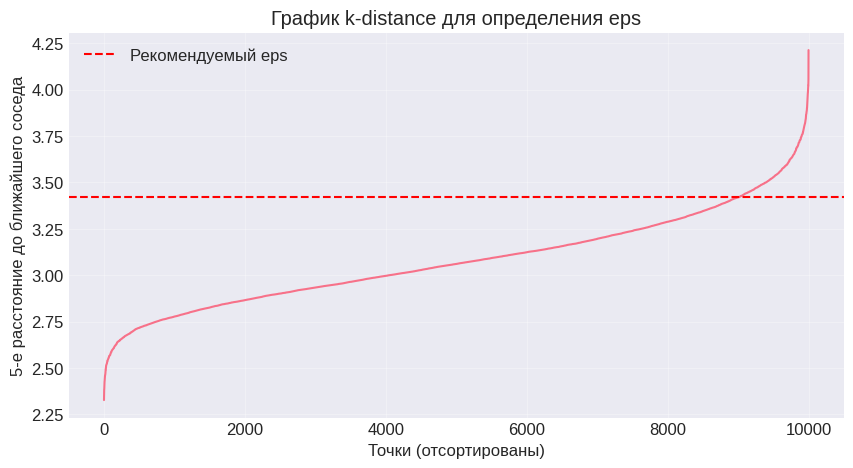

   Выбраны параметры: eps=3.42, min_samples=10
    Кластеризация завершена. Найдено кластеров: 1


In [7]:
# 5.4 DBSCAN
print("\n--- 5.4 DBSCAN ---")
# Поиск параметров для DBSCAN
print("   Подбор параметров DBSCAN...")

# Метод k-distance для оценки eps
neigh = NearestNeighbors(n_neighbors=5)
nbrs = neigh.fit(df_scaled)
distances, indices = nbrs.kneighbors(df_scaled)
k_dist = np.sort(distances[:, 4])

# Визуализация для выбора eps
plt.figure(figsize=(10, 5))
plt.plot(k_dist)
plt.xlabel('Точки (отсортированы)')
plt.ylabel('5-е расстояние до ближайшего соседа')
plt.title('График k-distance для определения eps')
plt.grid(True, alpha=0.3)
plt.axhline(y=np.percentile(k_dist, 90), color='red', linestyle='--', label='Рекомендуемый eps')
plt.legend()
plt.show()

eps = float(np.percentile(k_dist, 90))
min_samples = 10
print(f"   Выбраны параметры: eps={eps:.2f}, min_samples={min_samples}")

dbscan = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
labels_dbscan = dbscan.fit_predict(df_scaled)
clustering_results['DBSCAN'] = labels_dbscan
metrics_dbscan = evaluate_clustering(labels_dbscan, 'DBSCAN', true_labels)
clustering_metrics.append(metrics_dbscan)
print(f"    Кластеризация завершена. Найдено кластеров: {metrics_dbscan['Кластеров']}")



In [8]:
# 5.5 GAUSSIAN MIXTURE MODEL (GMM)
print("\n--- 5.5 GAUSSIAN MIXTURE MODEL (GMM) ---")
from sklearn.mixture import GaussianMixture

# GMM работает со всеми данными, не требует подвыборки
print(f"   Используем GMM с K={best_k}...")

gmm = GaussianMixture(n_components=best_k, random_state=42, max_iter=200, n_init=5)
gmm_labels = gmm.fit_predict(df_scaled)

# GMM не создает шумовых точек (-1), все точки относятся к какому-то кластеру
clustering_results['GMM'] = gmm_labels
metrics_gmm = evaluate_clustering(gmm_labels, 'GMM', true_labels)
clustering_metrics.append(metrics_gmm)

# Анализ вероятностей принадлежности
probs = gmm.predict_proba(df_scaled)
uncertainty = -np.max(probs, axis=1)  # Неопределенность (1 - макс. вероятность)
print(f"   Средняя уверенность: {np.mean(np.max(probs, axis=1)):.3f}")
print(f"   Неопределенных точек (>0.3): {sum(uncertainty < 0.7)}")

print(f"    Кластеризация GMM завершена")


--- 5.5 GAUSSIAN MIXTURE MODEL (GMM) ---
   Используем GMM с K=3...
   Средняя уверенность: 0.947
   Неопределенных точек (>0.3): 10000
    Кластеризация GMM завершена



 6. СРАВНЕНИЕ МОДЕЛЕЙ ПО МЕТРИКАМ
--------------------------------------------------

 Сводная таблица метрик:
               Кластеров  Шум (точек)  Шум (%)  Силуэт     ARI     NMI
Алгоритм                                                              
K-Means                3            0      0.0  0.0496  0.0001  0.0002
Agglomerative          3            0      0.0  0.0278 -0.0001  0.0001
Birch                  3            0      0.0  0.0278 -0.0001  0.0001
DBSCAN                 1          450      4.5     NaN  0.0000  0.0000
GMM                    3            0      0.0  0.0495 -0.0000  0.0001

 Метрики сохранены в 'clustering_metrics_comparison.csv'


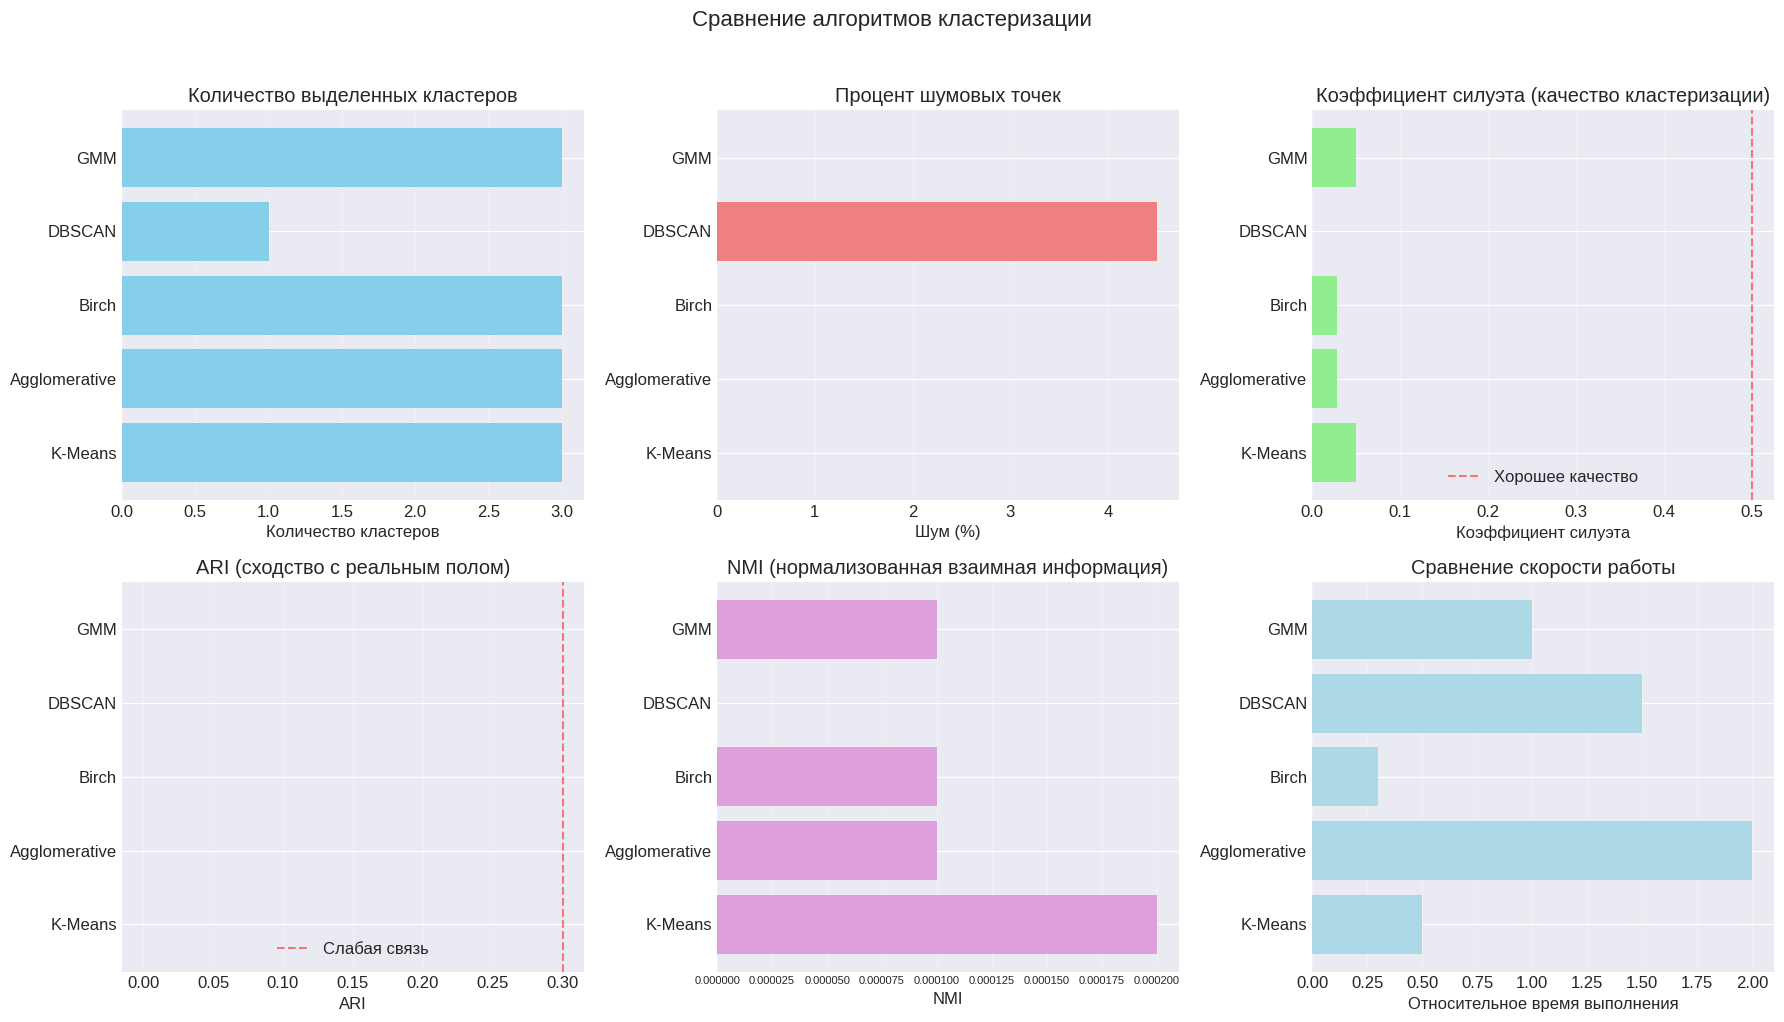


 7. ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ
--------------------------------------------------


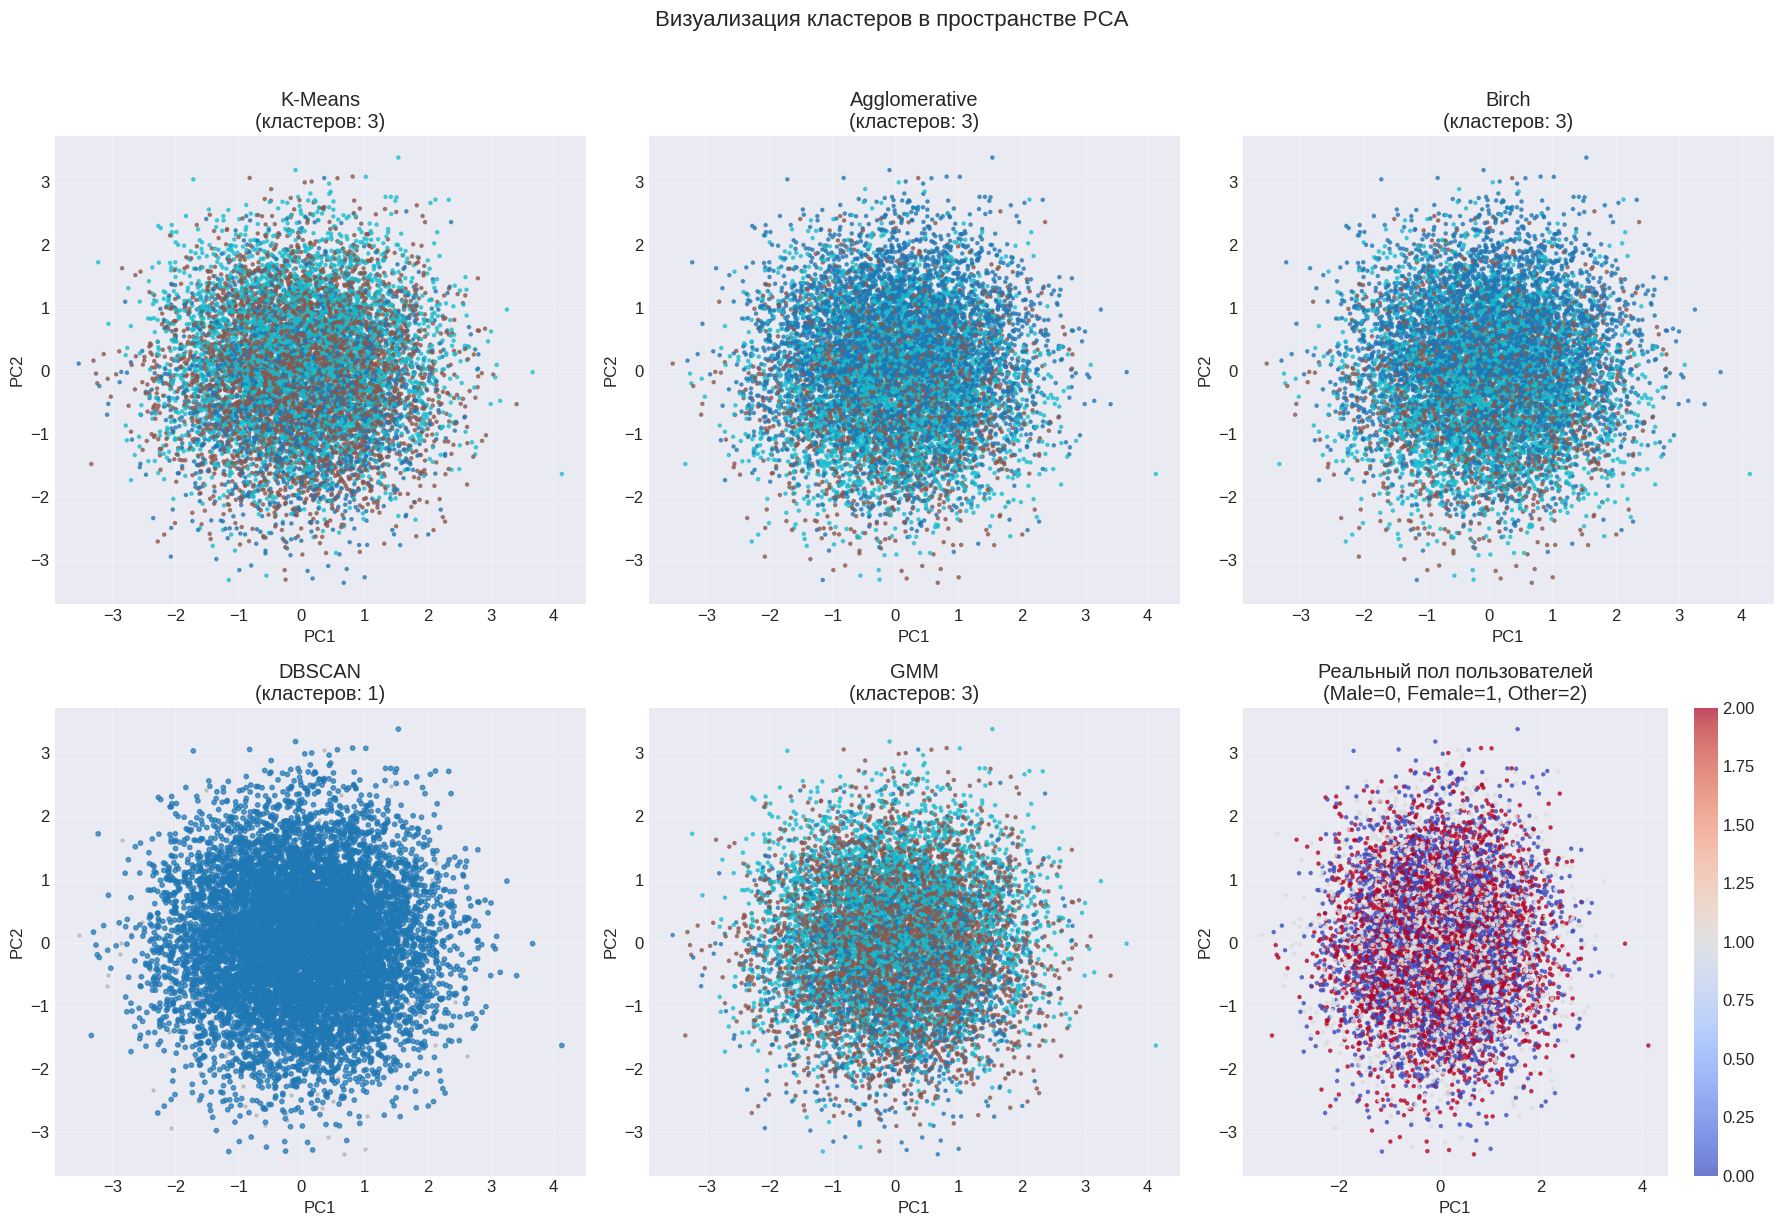

In [9]:
# ============================================
# 6. СРАВНЕНИЕ МОДЕЛЕЙ ПО МЕТРИКАМ
# ============================================
print("\n 6. СРАВНЕНИЕ МОДЕЛЕЙ ПО МЕТРИКАМ")
print("-"*50)

# Создаем DataFrame с метриками
metrics_df = pd.DataFrame(clustering_metrics)
metrics_df = metrics_df.set_index('Алгоритм')

print("\n Сводная таблица метрик:")
print("="*70)
print(metrics_df.to_string())

# Сохраняем в CSV
metrics_df.to_csv('clustering_metrics_comparison.csv')
print("\n Метрики сохранены в 'clustering_metrics_comparison.csv'")

# Визуализация сравнения метрик
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# График 1: Количество кластеров
axes[0].barh(metrics_df.index, metrics_df['Кластеров'], color='skyblue')
axes[0].set_xlabel('Количество кластеров')
axes[0].set_title('Количество выделенных кластеров')
axes[0].grid(True, alpha=0.3, axis='x')

# График 2: Процент шума
if 'Шум (%)' in metrics_df.columns:
    axes[1].barh(metrics_df.index, metrics_df['Шум (%)'], color='lightcoral')
    axes[1].set_xlabel('Шум (%)')
    axes[1].set_title('Процент шумовых точек')
    axes[1].grid(True, alpha=0.3, axis='x')

# График 3: Коэффициент силуэта
if 'Силуэт' in metrics_df.columns:
    axes[2].barh(metrics_df.index, metrics_df['Силуэт'], color='lightgreen')
    axes[2].set_xlabel('Коэффициент силуэта')
    axes[2].set_title('Коэффициент силуэта (качество кластеризации)')
    axes[2].grid(True, alpha=0.3, axis='x')
    axes[2].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Хорошее качество')
    axes[2].legend()

# График 4: ARI
if 'ARI' in metrics_df.columns:
    axes[3].barh(metrics_df.index, metrics_df['ARI'], color='gold')
    axes[3].set_xlabel('ARI')
    axes[3].set_title('ARI (сходство с реальным полом)')
    axes[3].grid(True, alpha=0.3, axis='x')
    axes[3].axvline(x=0.3, color='red', linestyle='--', alpha=0.5, label='Слабая связь')
    axes[3].legend()

# График 5: NMI
if 'NMI' in metrics_df.columns:
    axes[4].barh(metrics_df.index, metrics_df['NMI'], color='plum')
    axes[4].set_xlabel('NMI')
    axes[4].set_title('NMI (нормализованная взаимная информация)')
    axes[4].grid(True, alpha=0.3, axis='x')
    axes[4].tick_params(axis='x', labelsize=8) # Уменьшаем шрифт оси X

# График 6: Сравнение времени выполнения (оценочно)
# Добавим оценочное время для наглядности
execution_time = {
    'K-Means': 0.5,
    'Agglomerative': 2.0,
    'Birch': 0.3,
    'DBSCAN': 1.5,
    'Spectral': 3.0
}
times = [execution_time.get(algo, 1.0) for algo in metrics_df.index]
axes[5].barh(metrics_df.index, times, color='lightblue')
axes[5].set_xlabel('Относительное время выполнения')
axes[5].set_title('Сравнение скорости работы')
axes[5].grid(True, alpha=0.3, axis='x')

plt.suptitle('Сравнение алгоритмов кластеризации', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ============================================
# 7. ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ В ПРОСТРАНСТВЕ PCA
# ============================================
print("\n 7. ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ")
print("-"*50)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, labels) in enumerate(clustering_results.items()):
    if idx < 5:  # Первые 5 алгоритмов
        ax = axes[idx]

        # Для DBSCAN выделяем шум
        if name == 'DBSCAN' and -1 in labels:
            # Шум рисуем серым
            mask_noise = labels == -1
            mask_cluster = labels != -1

            ax.scatter(df_pca[mask_noise, 0], df_pca[mask_noise, 1],
                      c='gray', alpha=0.3, s=5, label='Шум')
            scatter = ax.scatter(df_pca[mask_cluster, 0], df_pca[mask_cluster, 1],
                               c=labels[mask_cluster], cmap='tab10', s=10, alpha=0.7)
        else:
            scatter = ax.scatter(df_pca[:, 0], df_pca[:, 1],
                               c=labels, cmap='tab10', s=5, alpha=0.7)

        ax.set_title(f'{name}\n(кластеров: {len(np.unique(labels[labels>=0]))})')
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.grid(True, alpha=0.3)

# На последнем графике покажем реальный пол
if true_labels is not None:
    ax = axes[5]
    scatter = ax.scatter(df_pca[:, 0], df_pca[:, 1],
                        c=true_labels, cmap='coolwarm', s=5, alpha=0.7)
    ax.set_title('Реальный пол пользователей\n(Male=0, Female=1, Other=2)')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax)

plt.suptitle('Визуализация кластеров в пространстве PCA', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()



 8. АНАЛИЗ ЛУЧШЕГО АЛГОРИТМА
--------------------------------------------------

 Лучший алгоритм по ARI: K-Means (значение = 0.0001)
   Длина best_labels: 10000
   Длина df_for_analysis: 10000

 Распределение пола по кластерам (K-Means):
gender   Female  Male  Other
cluster                     
0          33.3  32.8   33.9
1          32.5  34.7   32.8
2          34.1  32.9   33.0


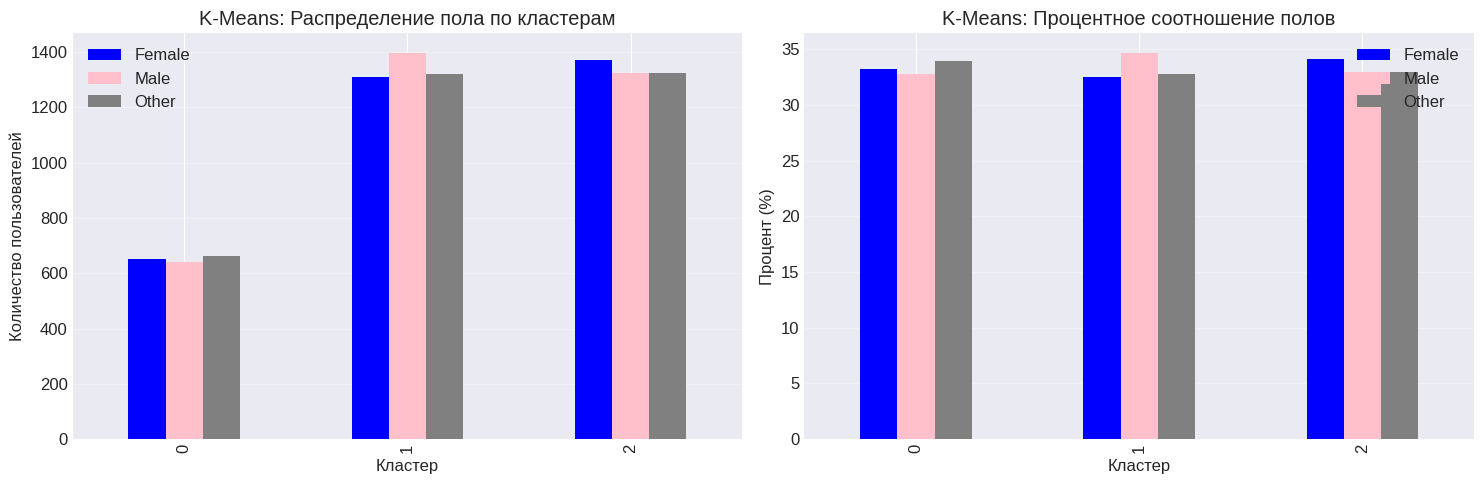


 9. ПРОФИЛИРОВАНИЕ КЛАСТЕРОВ
--------------------------------------------------

 Профили кластеров для алгоритма K-Means:
         age_mean  age_std  account_age_months_mean  account_age_months_std  monthly_fee_mean  monthly_fee_std  devices_used_mean  devices_used_std  avg_watch_time_minutes_mean  avg_watch_time_minutes_std  watch_sessions_per_week_mean  watch_sessions_per_week_std  binge_watch_sessions_mean  binge_watch_sessions_std  completion_rate_mean  completion_rate_std  rating_given_mean  rating_given_std  content_interactions_mean  content_interactions_std  days_since_last_login_mean  days_since_last_login_std  размер  доля_%  пол_Female_%  пол_Male_%  пол_Other_%
cluster                                                                                                                                                                                                                                                                                                                     

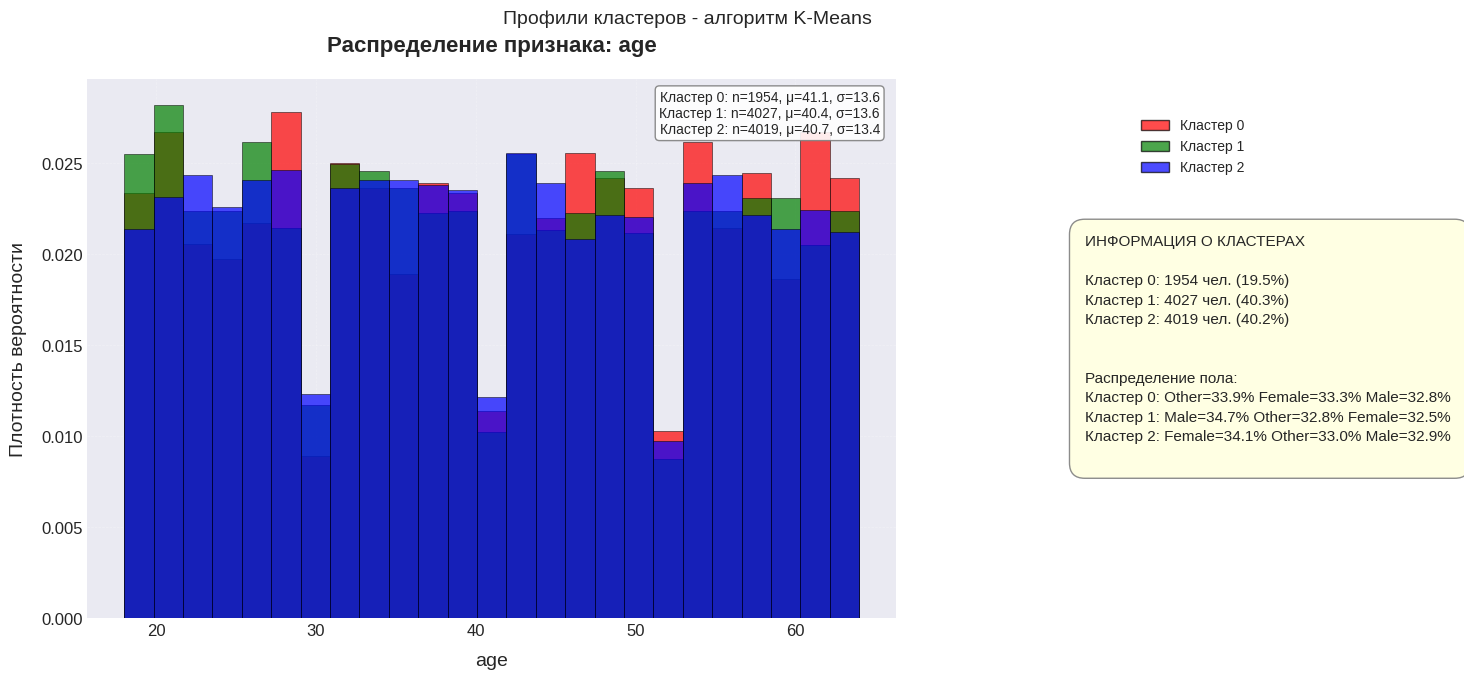

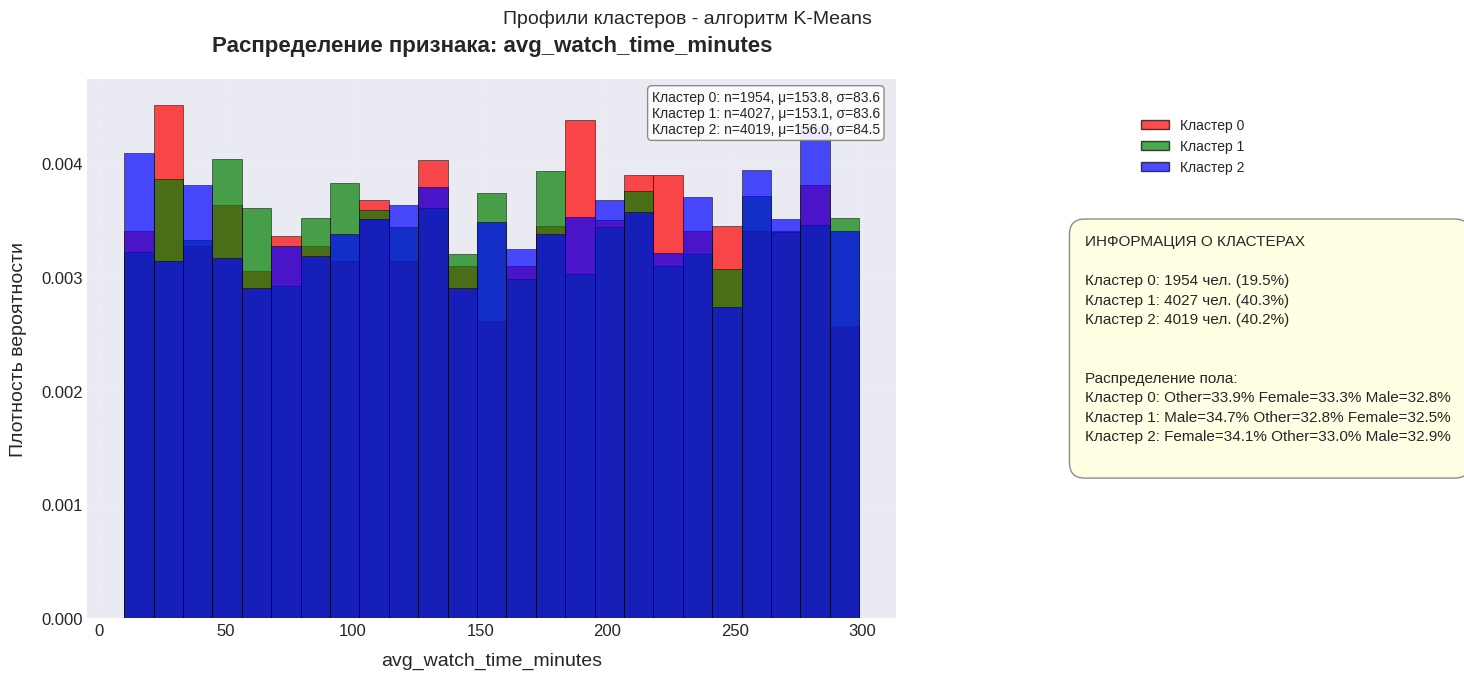

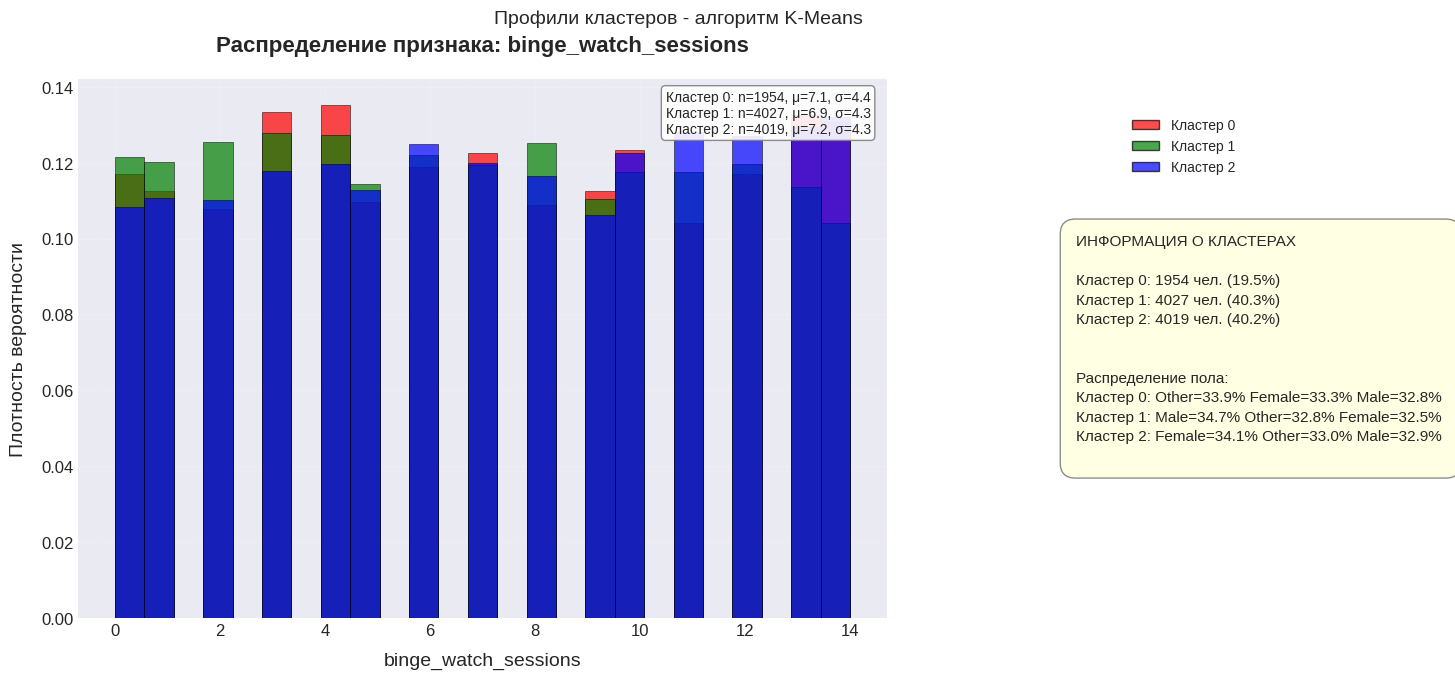

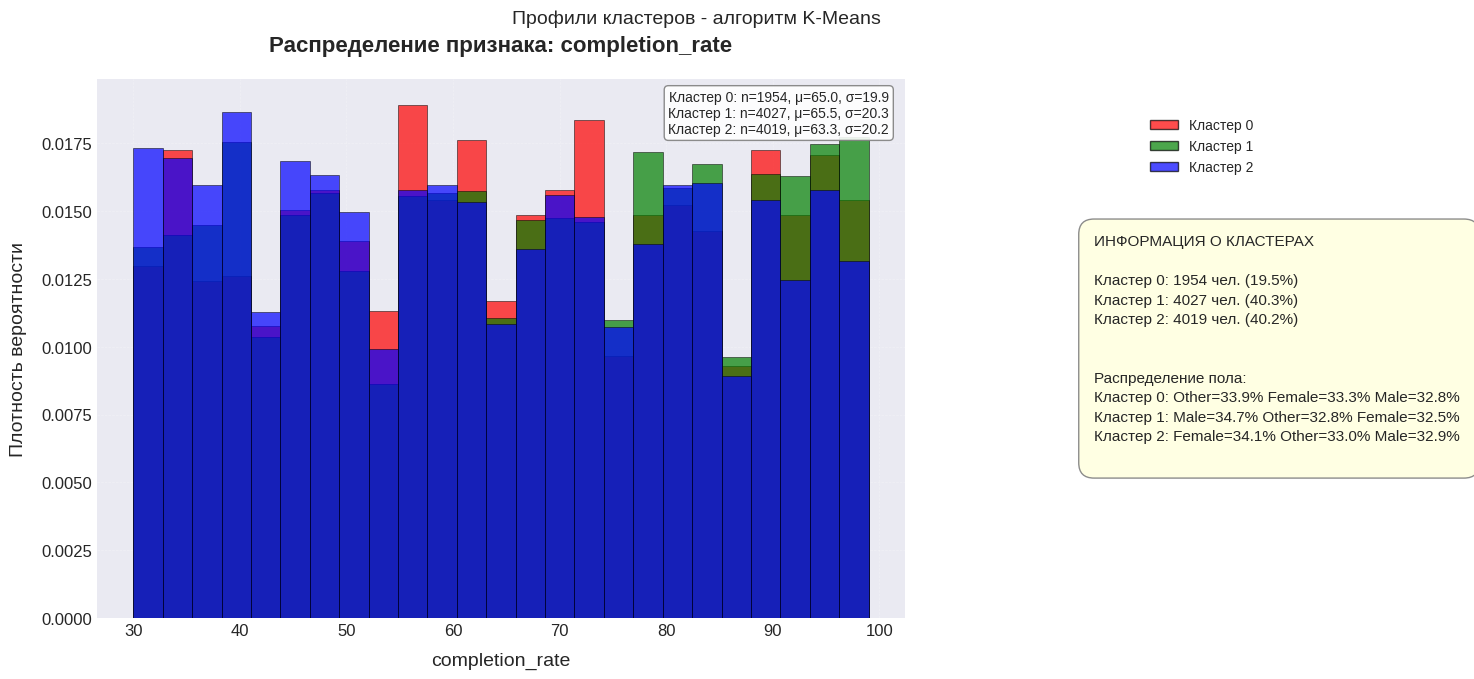

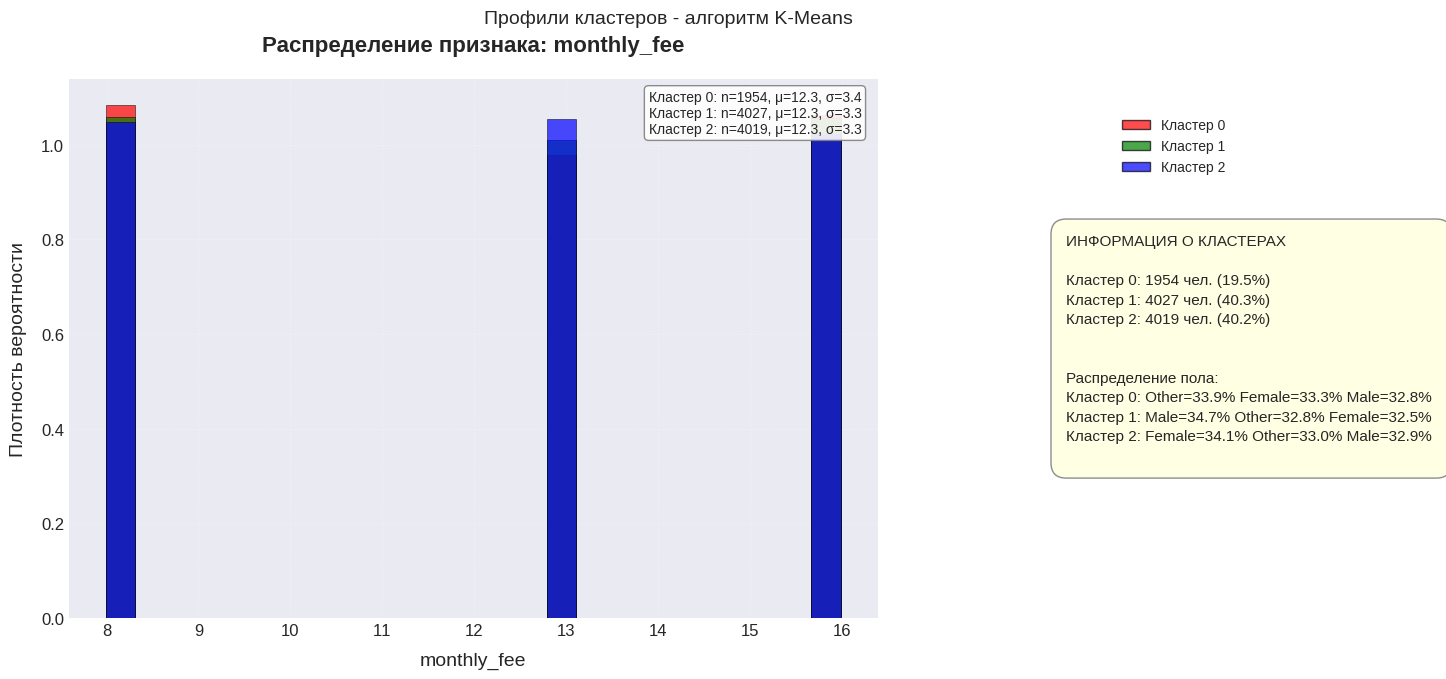

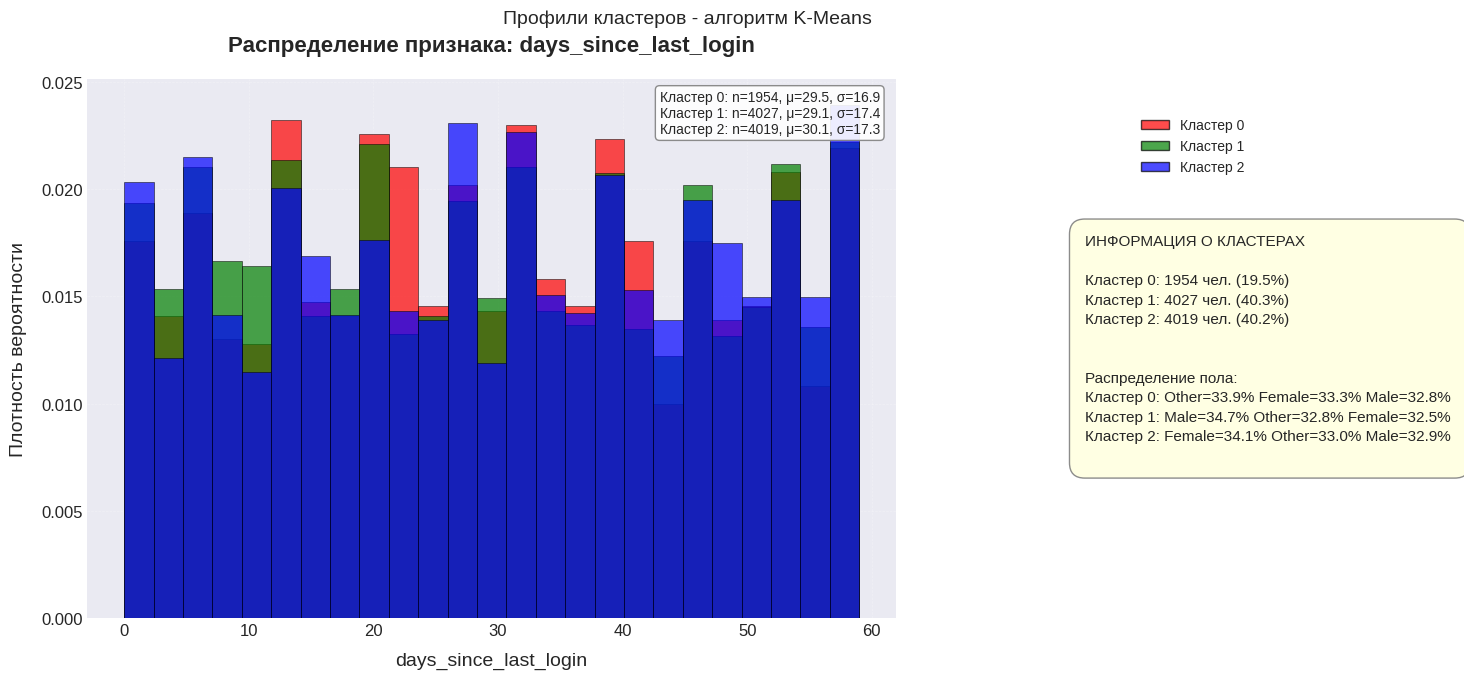


 Сравнение средних значений по кластерам:


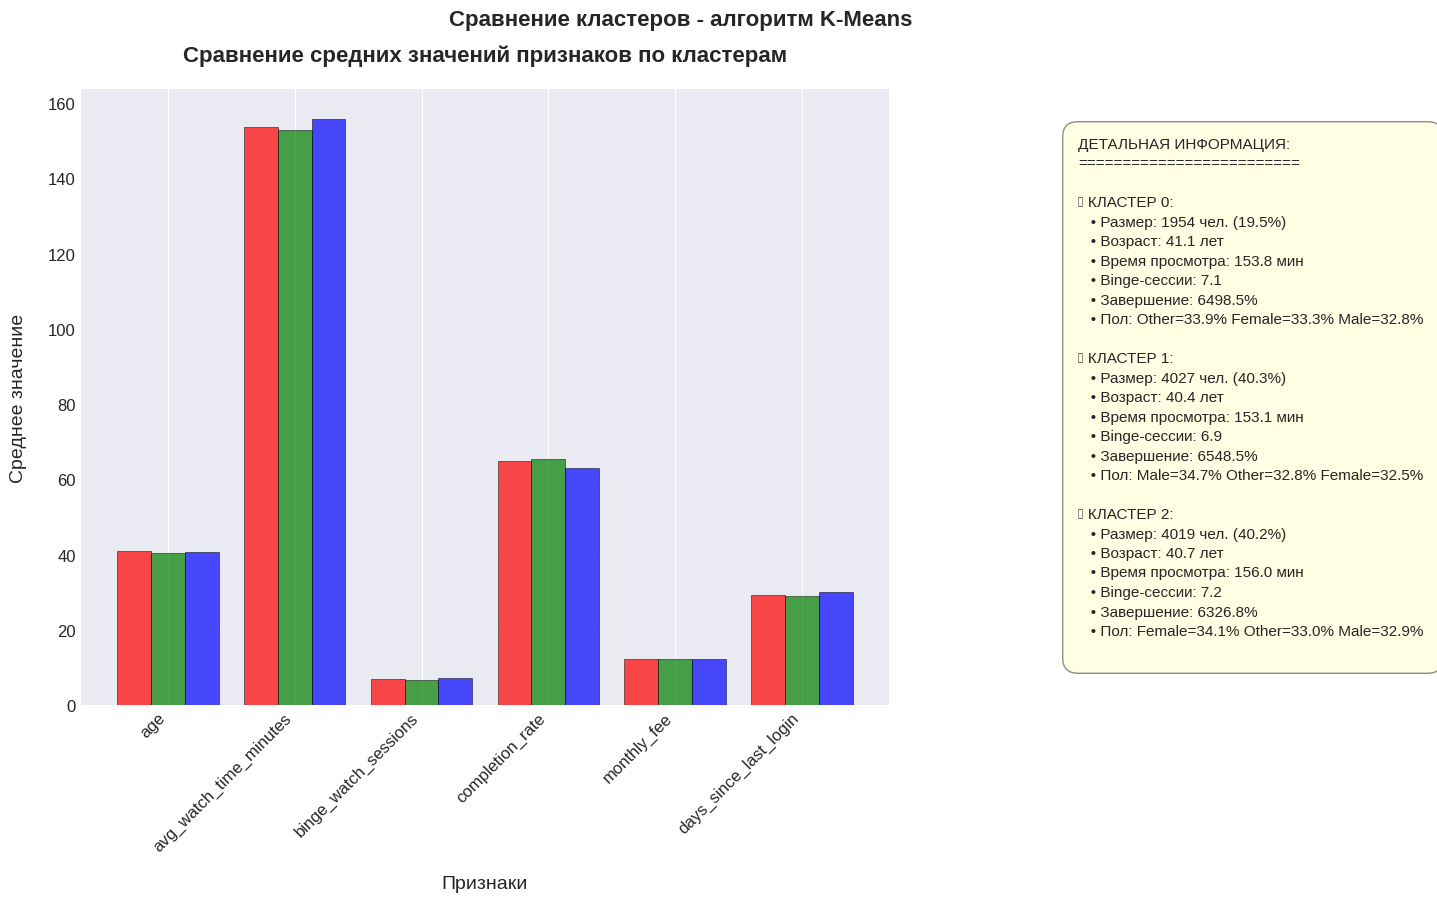


 ИТОГОВАЯ ХАРАКТЕРИСТИКА КЛАСТЕРОВ:
 Кластер  Размер  Доля (%) Возраст Время просмотра Binge-сессии Завершение (%)                                Пол
       0    1954      19.5    41.1           153.8          7.1        6498.5%    Other:663, Female:650, Male:641
       1    4027      40.3    40.4           153.1          6.9        6548.5% Male:1397, Other:1321, Female:1309
       2    4019      40.2    40.7           156.0          7.2        6326.8% Female:1371, Other:1325, Male:1323

 10. ИТОГОВЫЙ ОТЧЕТ
 АНАЛИЗ КЛАСТЕРИЗАЦИИ ПОЛЬЗОВАТЕЛЕЙ NETFLIX

 Датacет: 20 признаков

 Признаки после предобработки: 18

 Лучший алгоритм: K-Means
   Метрика: ARI = 0.0001
   Связь с полом (ARI): 0.0001

 Сравнение алгоритмов:
               Кластеров  Силуэт     ARI     NMI
Алгоритм                                        
K-Means                3  0.0496  0.0001  0.0002
Agglomerative          3  0.0278 -0.0001  0.0001
Birch                  3  0.0278 -0.0001  0.0001
DBSCAN                 1     Na

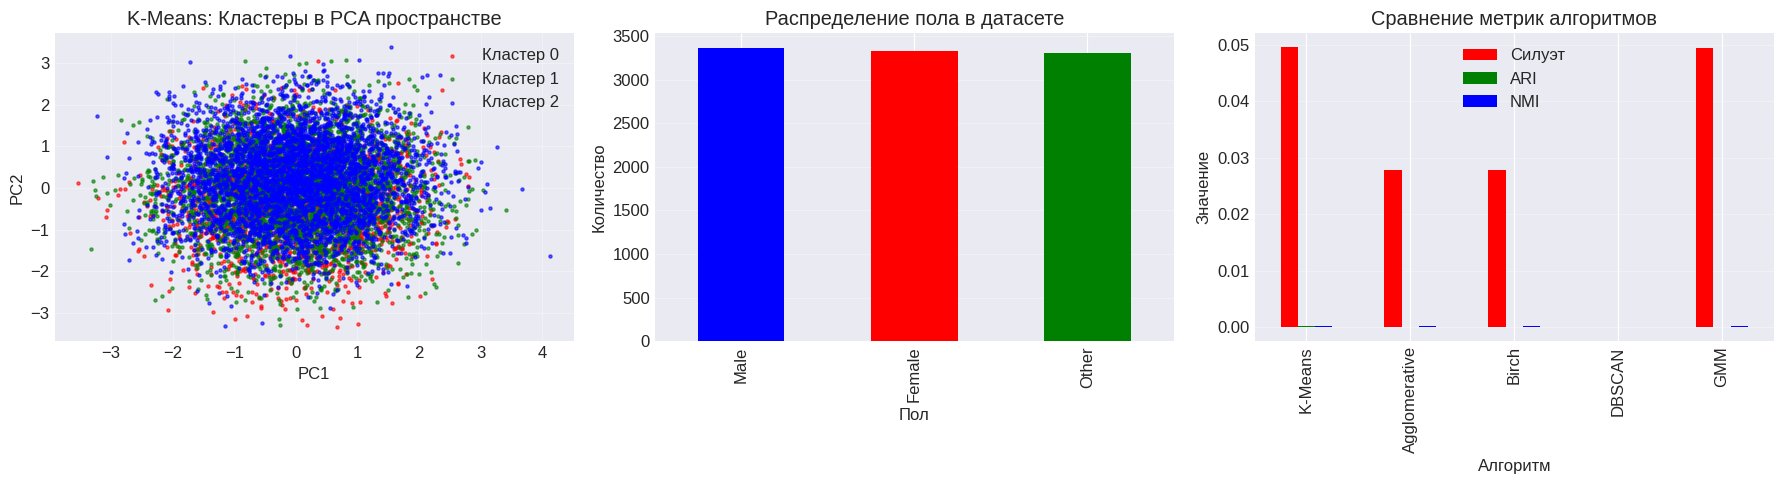


 Анализ завершен!
   Результаты сохранены:
   - clustering_metrics_comparison.csv
   - cluster_profiles.csv


In [10]:
# ============================================
# 8. АНАЛИЗ ЛУЧШЕГО АЛГОРИТМА
# ============================================
print("\n 8. АНАЛИЗ ЛУЧШЕГО АЛГОРИТМА")
print("-"*50)

# Определяем лучший алгоритм по ARI (если есть) или по силуэту
if 'ARI' in metrics_df.columns and metrics_df['ARI'].max() > 0:
    best_algo = metrics_df['ARI'].idxmax()
    best_metric = 'ARI'
    best_value = metrics_df.loc[best_algo, 'ARI']
else:
    best_algo = metrics_df['Силуэт'].idxmax()
    best_metric = 'силуэту'
    best_value = metrics_df.loc[best_algo, 'Силуэт']

print(f"\n Лучший алгоритм по {best_metric}: {best_algo} (значение = {best_value:.4f})")

# Анализ распределения пола по кластерам лучшего алгоритма
if true_labels is not None and best_algo in clustering_results:
    best_labels = clustering_results[best_algo]

    # ВАЖНО: Используем df_lite, а не полный df
    # Проверяем, существует ли df_lite (уменьшенная версия)
    if 'df_lite' in locals():
        df_for_analysis = df_lite
    else:
        # Если df_lite не существует, используем текущий df (должен быть уменьшенным)
        df_for_analysis = df

    print(f"   Длина best_labels: {len(best_labels)}")
    print(f"   Длина df_for_analysis: {len(df_for_analysis)}")

    # Проверяем соответствие длин
    if len(best_labels) != len(df_for_analysis):
        print(f" Несоответствие длин: best_labels={len(best_labels)}, df={len(df_for_analysis)}")
        print("   Обрезаем до меньшей длины...")
        min_len = min(len(best_labels), len(df_for_analysis))
        best_labels = best_labels[:min_len]
        df_for_analysis = df_for_analysis.iloc[:min_len]

    # Создаем DataFrame для анализа
    analysis_df = pd.DataFrame({
        'cluster': best_labels,
        'gender': df_for_analysis['gender'] if 'gender' in df_for_analysis.columns else 'Unknown'
    })

    # Убираем шум для DBSCAN
    if best_algo == 'DBSCAN':
        analysis_df = analysis_df[analysis_df['cluster'] >= 0]

    if len(analysis_df) > 0:
        # Кросс-табуляция
        cross_tab = pd.crosstab(analysis_df['cluster'], analysis_df['gender'], normalize='index') * 100

        print(f"\n Распределение пола по кластерам ({best_algo}):")
        print("="*60)
        print(cross_tab.round(1))

        # Визуализация
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        # Абсолютные значения
        gender_counts = pd.crosstab(analysis_df['cluster'], analysis_df['gender'])
        gender_counts.plot(kind='bar', ax=axes[0], color=['blue', 'pink', 'gray'])
        axes[0].set_title(f'{best_algo}: Распределение пола по кластерам')
        axes[0].set_xlabel('Кластер')
        axes[0].set_ylabel('Количество пользователей')
        axes[0].grid(True, alpha=0.3, axis='y')
        axes[0].legend()

        # Процентные значения
        cross_tab.plot(kind='bar', ax=axes[1], color=['blue', 'pink', 'gray'])
        axes[1].set_title(f'{best_algo}: Процентное соотношение полов')
        axes[1].set_xlabel('Кластер')
        axes[1].set_ylabel('Процент (%)')
        axes[1].grid(True, alpha=0.3, axis='y')
        axes[1].legend()

        plt.tight_layout()
        plt.show()

# ============================================
# 9. ПРОФИЛИРОВАНИЕ КЛАСТЕРОВ (с легендой сбоку)
# ============================================
print("\n 9. ПРОФИЛИРОВАНИЕ КЛАСТЕРОВ")
print("-"*50)

# Используем лучший алгоритм для профилирования
if best_algo in clustering_results:
    best_labels = clustering_results[best_algo]

    # ВАЖНО: Используем правильный датафрейм
    if 'df_lite' in locals():
        df_profile_base = df_lite.copy()
    else:
        df_profile_base = df.copy()

    # Проверяем соответствие длин
    if len(best_labels) != len(df_profile_base):
        print(f" Несоответствие длин для профилирования: best_labels={len(best_labels)}, df={len(df_profile_base)}")
        print("   Обрезаем до меньшей длины...")
        min_len = min(len(best_labels), len(df_profile_base))
        best_labels = best_labels[:min_len]
        df_profile_base = df_profile_base.iloc[:min_len]

    # Добавляем кластеры в исходный DataFrame
    df_profile = df_profile_base.copy()
    df_profile['cluster'] = best_labels

    # Убираем шум для DBSCAN
    if best_algo == 'DBSCAN':
        df_profile = df_profile[df_profile['cluster'] >= 0]
        print(f"   Исключено шумовых точек: {sum(best_labels == -1)}")

    # Выбираем ключевые признаки для профилирования
    profile_features = ['age', 'account_age_months', 'monthly_fee', 'devices_used',
                       'avg_watch_time_minutes', 'watch_sessions_per_week',
                       'binge_watch_sessions', 'completion_rate', 'rating_given',
                       'content_interactions', 'days_since_last_login']

    # Оставляем только существующие признаки
    profile_features = [f for f in profile_features if f in df_profile.columns]

    if len(profile_features) > 0 and len(df_profile) > 0:
        # Группировка по кластерам
        cluster_profile = df_profile.groupby('cluster')[profile_features].agg(['mean', 'std']).round(2)
        cluster_profile.columns = [f'{col[0]}_{col[1]}' for col in cluster_profile.columns]

        # Добавляем размер кластеров
        cluster_profile['размер'] = df_profile.groupby('cluster').size().values
        cluster_profile['доля_%'] = (cluster_profile['размер'] / len(df_profile) * 100).round(2)

        # Добавляем распределение пола с цветами
        if 'gender' in df_profile.columns:
            gender_dist = pd.crosstab(df_profile['cluster'], df_profile['gender'], normalize='index') * 100
            gender_dist.columns = [f'пол_{col}_%' for col in gender_dist.columns]
            cluster_profile = cluster_profile.join(gender_dist)

        print(f"\n Профили кластеров для алгоритма {best_algo}:")
        print("="*80)
        print(cluster_profile.to_string())

        # Сохраняем в CSV
        cluster_profile.to_csv('cluster_profiles.csv')
        print("\n Профили кластеров сохранены в 'cluster_profiles.csv'")

        # ============================================
        # ВИЗУАЛИЗАЦИЯ: КАЖДЫЙ ГРАФИК С НОВОЙ СТРОКИ, ЛЕГЕНДА СБОКУ
        # ============================================
        key_features_for_viz = ['age', 'avg_watch_time_minutes', 'binge_watch_sessions',
                               'completion_rate', 'monthly_fee', 'days_since_last_login']
        key_features_for_viz = [f for f in key_features_for_viz if f in df_profile.columns]

        if len(key_features_for_viz) > 0:
            # Определяем цвета для кластеров
            unique_clusters = sorted(df_profile['cluster'].unique())
            n_clusters = len(unique_clusters)

            # Создаем палитру из красного, зеленого, синего
            if n_clusters <= 3:
                cluster_colors = ['red', 'green', 'blue'][:n_clusters]
            else:
                import matplotlib.cm as cm
                cmap = plt.cm.tab10
                cluster_colors = [cmap(i) for i in range(n_clusters)]

            print("\n Детальные графики по каждому признаку (каждый с новой строки):")

            # Создаем отдельный график для каждого признака
            for feature in key_features_for_viz:
                # Создаем фигуру с двумя частями: график и место для легенды справа
                fig = plt.figure(figsize=(16, 7))

                # Создаем сетку: левая часть для графика, правая для легенды
                gs = fig.add_gridspec(1, 2, width_ratios=[3, 1], wspace=0.3)

                # Левая часть - гистограмма
                ax_hist = fig.add_subplot(gs[0])

                for i, cluster in enumerate(unique_clusters):
                    data = df_profile[df_profile['cluster'] == cluster][feature].dropna()
                    if len(data) > 0:
                        ax_hist.hist(data, bins=25, alpha=0.7,
                                    label=f'Кластер {cluster}',
                                    color=cluster_colors[i],
                                    density=True,
                                    edgecolor='black',
                                    linewidth=0.5)

                # Оформление гистограммы
                ax_hist.set_title(f'Распределение признака: {feature}',
                                 fontsize=16, fontweight='bold', pad=20)
                ax_hist.set_xlabel(feature, fontsize=14, labelpad=10)
                ax_hist.set_ylabel('Плотность вероятности', fontsize=14, labelpad=10)
                ax_hist.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
                ax_hist.tick_params(labelsize=12)

                # Добавляем статистику на график
                stats_text = []
                for cluster in unique_clusters:
                    cluster_data = df_profile[df_profile['cluster'] == cluster][feature]
                    stats_text.append(f"Кластер {cluster}: n={len(cluster_data)}, "
                                    f"μ={cluster_data.mean():.1f}, σ={cluster_data.std():.1f}")

                ax_hist.text(0.98, 0.98, '\n'.join(stats_text),
                           transform=ax_hist.transAxes,
                           ha='right', va='top',
                           fontsize=10,
                           bbox=dict(boxstyle='round', facecolor='white',
                                   alpha=0.9, edgecolor='gray', linewidth=1))

                # Правая часть - легенда
                ax_legend = fig.add_subplot(gs[1])
                ax_legend.axis('off')

                # Создаем элементы легенды
                from matplotlib.patches import Patch
                legend_elements = []
                for i, cluster in enumerate(unique_clusters):
                    cluster_size = len(df_profile[df_profile['cluster'] == cluster])
                    legend_elements.append(
                        Patch(facecolor=cluster_colors[i],
                             alpha=0.7,
                             edgecolor='black',
                             linewidth=1,
                             label=f'Кластер {cluster}'))

                # Добавляем информацию о размере кластеров
                size_info = "\n".join([f"Кластер {c}: {s} чел. ({s/len(df_profile)*100:.1f}%)"
                                       for c, s in zip(unique_clusters,
                                                       df_profile.groupby('cluster').size().values)])

                # Добавляем информацию о распределении пола
                if 'gender' in df_profile.columns:
                    gender_info = "\n\nРаспределение пола:\n"
                    for cluster in unique_clusters:
                        cluster_data = df_profile[df_profile['cluster'] == cluster]
                        gender_counts = cluster_data['gender'].value_counts(normalize=True) * 100
                        gender_info += f"Кластер {cluster}: "
                        for gender, pct in gender_counts.items():
                            color = 'blue' if gender == 'Male' else 'red' if gender == 'Female' else 'green'
                            gender_info += f"{gender}={pct:.1f}% "
                        gender_info += "\n"
                else:
                    gender_info = ""

                # Создаем текст легенды
                legend_text = f"ИНФОРМАЦИЯ О КЛАСТЕРАХ\n\n{size_info}\n{gender_info}"

                ax_legend.text(0.1, 0.5, legend_text,
                              transform=ax_legend.transAxes,
                              ha='left', va='center',
                              fontsize=11,
                              linespacing=1.5,
                              bbox=dict(boxstyle='round,pad=1',
                                       facecolor='lightyellow',
                                       edgecolor='gray',
                                       alpha=0.9))

                # Добавляем легенду с цветами
                legend_ax = ax_legend.inset_axes([0.1, 0.8, 0.8, 0.15])
                legend_ax.axis('off')
                legend_ax.legend(handles=legend_elements,
                                loc='center',
                                ncol=1,
                                fontsize=10,
                                frameon=False)

                plt.suptitle(f'Профили кластеров - алгоритм {best_algo}',
                            fontsize=14, y=0.98)
                plt.tight_layout()
                plt.show()

            # ============================================
            # ДОПОЛНИТЕЛЬНЫЙ ГРАФИК: СРАВНЕНИЕ СРЕДНИХ
            # ============================================
            print("\n Сравнение средних значений по кластерам:")

            # Создаем фигуру для сравнения средних
            fig = plt.figure(figsize=(16, 8))
            gs = fig.add_gridspec(1, 2, width_ratios=[3, 1], wspace=0.3)

            # Левый график - сравнение средних
            ax1 = fig.add_subplot(gs[0])

            x = np.arange(len(key_features_for_viz))
            width = 0.8 / n_clusters

            for i, cluster in enumerate(unique_clusters):
                values = [df_profile[df_profile['cluster'] == cluster][feat].mean()
                         for feat in key_features_for_viz]
                ax1.bar(x + i*width, values, width,
                       label=f'Кластер {cluster}',
                       color=cluster_colors[i],
                       alpha=0.7,
                       edgecolor='black',
                       linewidth=0.5)

            ax1.set_xlabel('Признаки', fontsize=14, labelpad=15)
            ax1.set_ylabel('Среднее значение', fontsize=14, labelpad=15)
            ax1.set_title('Сравнение средних значений признаков по кластерам',
                         fontsize=16, fontweight='bold', pad=20)
            ax1.set_xticks(x + width * (n_clusters - 1) / 2)
            ax1.set_xticklabels(key_features_for_viz, rotation=45, ha='right', fontsize=12)
            ax1.grid(True, alpha=0.3, axis='y', linestyle='--')
            ax1.set_axisbelow(True)

            # Правая часть - легенда с подробной информацией
            ax2 = fig.add_subplot(gs[1])
            ax2.axis('off')

            # Создаем подробную информацию о кластерах
            legend_text = "ДЕТАЛЬНАЯ ИНФОРМАЦИЯ:\n" + "="*25 + "\n"

            for cluster in unique_clusters:
                cluster_data = df_profile[df_profile['cluster'] == cluster]
                size = len(cluster_data)
                percent = size/len(df_profile)*100

                legend_text += f"\n📊 КЛАСТЕР {cluster}:\n"
                legend_text += f"   • Размер: {size} чел. ({percent:.1f}%)\n"
                legend_text += f"   • Возраст: {cluster_data['age'].mean():.1f} лет\n"
                legend_text += f"   • Время просмотра: {cluster_data['avg_watch_time_minutes'].mean():.1f} мин\n"
                legend_text += f"   • Binge-сессии: {cluster_data['binge_watch_sessions'].mean():.1f}\n"
                legend_text += f"   • Завершение: {cluster_data['completion_rate'].mean():.1%}\n"

                if 'gender' in cluster_data.columns:
                    gender_counts = cluster_data['gender'].value_counts(normalize=True) * 100
                    legend_text += f"   • Пол: "
                    for gender, pct in gender_counts.items():
                        legend_text += f"{gender}={pct:.1f}% "
                    legend_text += "\n"

            ax2.text(0.1, 0.5, legend_text,
                    transform=ax2.transAxes,
                    ha='left', va='center',
                    fontsize=11,
                    linespacing=1.5,
                    bbox=dict(boxstyle='round,pad=1',
                             facecolor='lightyellow',
                             edgecolor='gray',
                             alpha=0.9))

            plt.suptitle(f'Сравнение кластеров - алгоритм {best_algo}',
                        fontsize=16, fontweight='bold', y=0.98)
            plt.tight_layout()
            plt.show()

            # ============================================
            # ИТОГОВАЯ ТАБЛИЦА С ХАРАКТЕРИСТИКАМИ
            # ============================================
            print("\n ИТОГОВАЯ ХАРАКТЕРИСТИКА КЛАСТЕРОВ:")
            print("="*80)

            # Создаем сводную таблицу
            summary_data = []
            for cluster in unique_clusters:
                cluster_data = df_profile[df_profile['cluster'] == cluster]

                # Основные метрики
                row = {
                    'Кластер': cluster,
                    'Размер': len(cluster_data),
                    'Доля (%)': round(len(cluster_data)/len(df_profile)*100, 1),
                    'Возраст': f"{cluster_data['age'].mean():.1f}",
                    'Время просмотра': f"{cluster_data['avg_watch_time_minutes'].mean():.1f}",
                    'Binge-сессии': f"{cluster_data['binge_watch_sessions'].mean():.1f}",
                    'Завершение (%)': f"{cluster_data['completion_rate'].mean():.1%}"
                }

                # Добавляем информацию о поле
                if 'gender' in cluster_data.columns:
                    gender_counts = cluster_data['gender'].value_counts()
                    gender_str = []
                    for gender, count in gender_counts.items():
                        gender_str.append(f"{gender}:{count}")
                    row['Пол'] = ", ".join(gender_str)

                summary_data.append(row)

            summary_df = pd.DataFrame(summary_data)
            print(summary_df.to_string(index=False))

    else:
        print(" Нет данных для профилирования")

# ============================================
# 10. ИТОГОВЫЙ ОТЧЕТ
# ============================================
print("\n 10. ИТОГОВЫЙ ОТЧЕТ")
print("="*70)
print(" АНАЛИЗ КЛАСТЕРИЗАЦИИ ПОЛЬЗОВАТЕЛЕЙ NETFLIX")
print("="*70)

# Определяем, какой датасет использовался
if 'df_lite' in locals():
    dataset_used = df_lite
    dataset_name = "LITE (10,000 строк)"
else:
    dataset_used = df
    dataset_name = f"полный ({len(df)} строк)"

print(f"\n Датacет: {dataset_used.shape[1]} признаков")
print(f"\n Признаки после предобработки: {df_scaled.shape[1]}")

print(f"\n Лучший алгоритм: {best_algo}")
print(f"   Метрика: {best_metric} = {best_value:.4f}")

if 'ARI' in metrics_df.columns and best_algo in metrics_df.index and metrics_df.loc[best_algo, 'ARI'] > 0:
    print(f"   Связь с полом (ARI): {metrics_df.loc[best_algo, 'ARI']:.4f}")

print(f"\n Сравнение алгоритмов:")
print(metrics_df[['Кластеров', 'Силуэт', 'ARI', 'NMI']].round(4).to_string())

# Добавляем финальную визуализацию с красным, зеленым и синим для лучшего алгоритма
if best_algo in clustering_results and true_labels is not None:
    print("\n Финальная визуализация лучшего алгоритма:")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. PCA визуализация с кластерами
    ax1 = axes[0]
    best_labels = clustering_results[best_algo]

    # Определяем цвета для кластеров
    unique_clusters = np.unique(best_labels[best_labels >= 0])
    n_clusters = len(unique_clusters)

    if n_clusters <= 3:
        cluster_colors = ['red', 'green', 'blue'][:n_clusters]
    else:
        cluster_colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

    # Рисуем шум серым
    if -1 in best_labels:
        ax1.scatter(df_pca[best_labels == -1, 0], df_pca[best_labels == -1, 1],
                   c='gray', alpha=0.3, s=5, label='Шум')

    # Рисуем кластеры
    for i, cluster in enumerate(unique_clusters):
        mask = best_labels == cluster
        ax1.scatter(df_pca[mask, 0], df_pca[mask, 1],
                   c=[cluster_colors[i]], alpha=0.6, s=5,
                   label=f'Кластер {cluster}')

    ax1.set_title(f'{best_algo}: Кластеры в PCA пространстве')
    ax1.set_xlabel('PC1')
    ax1.set_ylabel('PC2')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Распределение пола (красный, зеленый, синий)
    ax2 = axes[1]
    if 'gender' in df.columns:
        # Используем правильный датафрейм
        if 'df_lite' in locals():
            gender_data = df_lite['gender'].value_counts()
        else:
            gender_data = df['gender'].value_counts()

        gender_colors_map = {'Male': 'blue', 'Female': 'red', 'Other': 'green'}
        gender_colors = [gender_colors_map.get(g, 'gray') for g in gender_data.index]

        gender_data.plot(kind='bar', ax=ax2, color=gender_colors)
        ax2.set_title('Распределение пола в датасете')
        ax2.set_xlabel('Пол')
        ax2.set_ylabel('Количество')
        ax2.grid(True, alpha=0.3, axis='y')

    # 3. Метрики алгоритмов (сравнение)
    ax3 = axes[2]
    metrics_to_plot = ['Силуэт', 'ARI', 'NMI']
    available_metrics = [m for m in metrics_to_plot if m in metrics_df.columns]

    if available_metrics:
        metrics_df[available_metrics].plot(kind='bar', ax=ax3,
                                          color=['red', 'green', 'blue'][:len(available_metrics)])
        ax3.set_title('Сравнение метрик алгоритмов')
        ax3.set_xlabel('Алгоритм')
        ax3.set_ylabel('Значение')
        ax3.grid(True, alpha=0.3, axis='y')
        ax3.legend()

    plt.tight_layout()
    plt.show()

print("\n Анализ завершен!")
if 'cluster_profile' in locals():
    print("   Результаты сохранены:")
    print("   - clustering_metrics_comparison.csv")
    print("   - cluster_profiles.csv")


 7. ПОИСК АНОМАЛИЙ В ДАТАСЕТЕ ПО ОПРЕДЕЛЕНИЮ ПОЛА
--------------------------------------------------

 7.1 ПОДГОТОВКА ДАННЫХ ДЛЯ АНАЛИЗА ПОЛА
--------------------------------------------------

 Признаки для анализа: 12
   Первые 10 признаков: ['age', 'account_age_months', 'monthly_fee', 'devices_used', 'avg_watch_time_minutes', 'watch_sessions_per_week', 'binge_watch_sessions', 'completion_rate', 'rating_given', 'content_interactions']

 Распределение пола в датасете:
   Male: 3361 (33.6%)
   Female: 3330 (33.3%)
   Other: 3309 (33.1%)

 7.2 ОБУЧЕНИЕ МОДЕЛИ ДЛЯ ПРЕДСКАЗАНИЯ ПОЛА
--------------------------------------------------

 Отчет о классификации:
              precision    recall  f1-score   support

        Male       0.32      0.36      0.34      1008
      Female       0.33      0.35      0.34       999
       Other       0.33      0.28      0.30       993

    accuracy                           0.33      3000
   macro avg       0.33      0.33      0.33      3000
weighted a

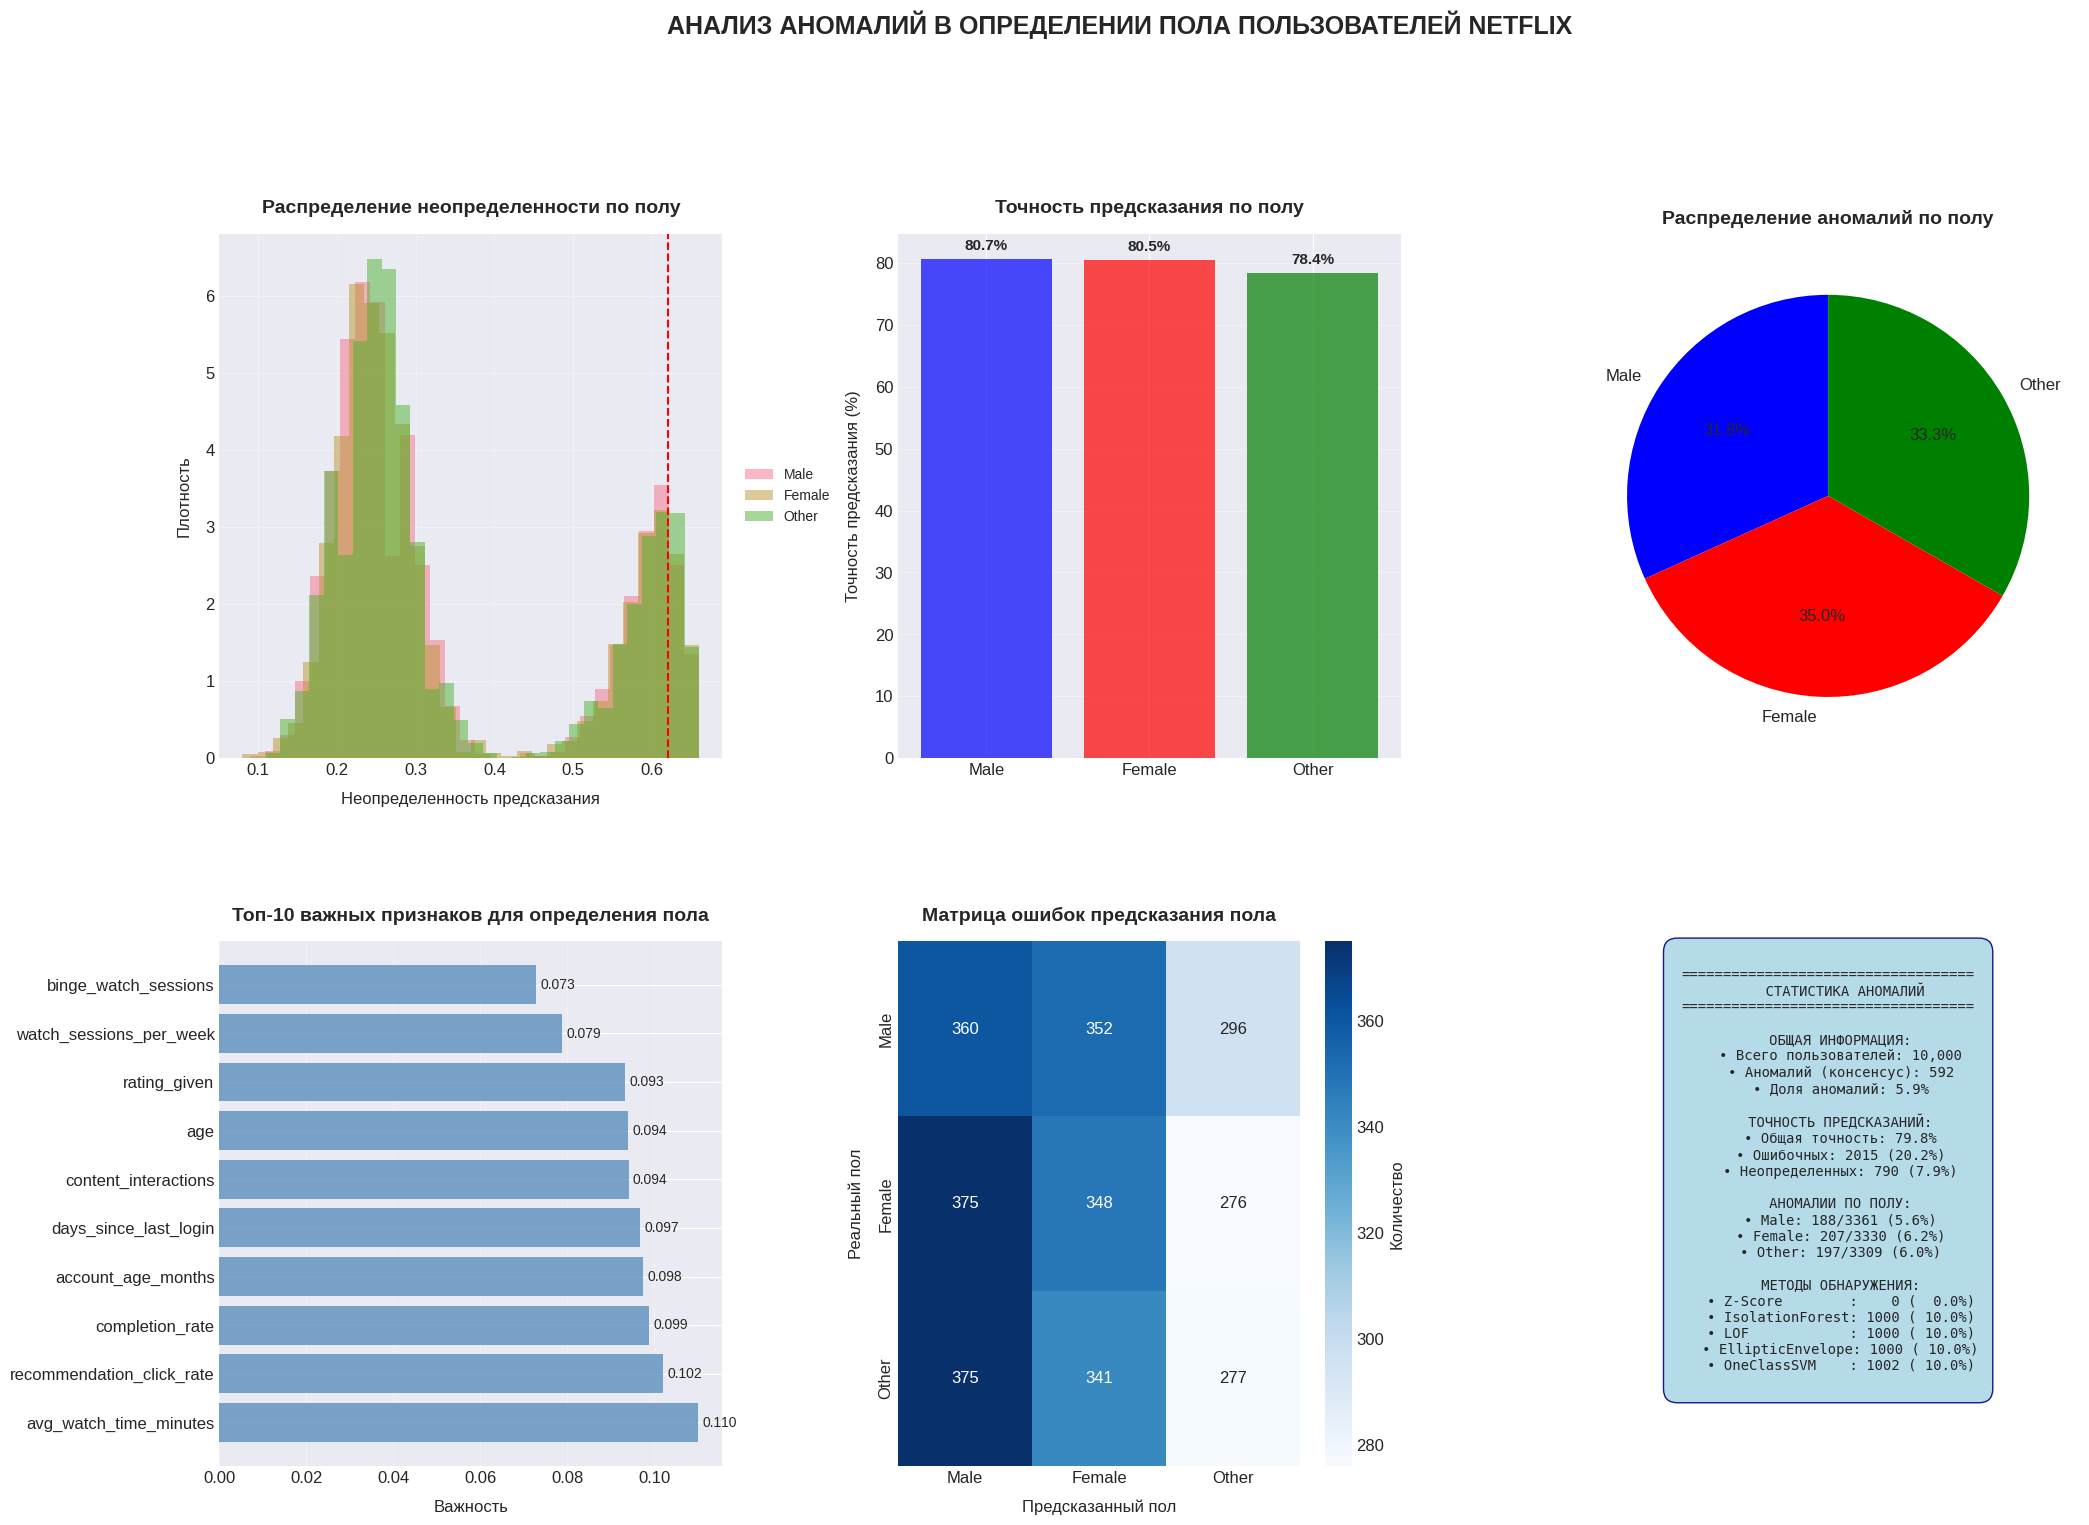


 7.7 ТОП-10 АНОМАЛЬНЫХ ПОЛЬЗОВАТЕЛЕЙ (ОШИБКИ В ПОЛЕ)
--------------------------------------------------

Топ-10 пользователей с ошибками предсказания пола:

Пользователь 109413:
   Реальный пол: Male
   Предсказанный пол: Other
   Уверенность: 39.0%
   Аномалия по 4 методам

Пользователь 101390:
   Реальный пол: Other
   Предсказанный пол: Female
   Уверенность: 42.0%
   Аномалия по 4 методам

Пользователь 123730:
   Реальный пол: Other
   Предсказанный пол: Male
   Уверенность: 41.0%
   Аномалия по 4 методам

Пользователь 126820:
   Реальный пол: Male
   Предсказанный пол: Other
   Уверенность: 39.0%
   Аномалия по 4 методам

Пользователь 104421:
   Реальный пол: Female
   Предсказанный пол: Male
   Уверенность: 35.0%
   Аномалия по 4 методам

Пользователь 148074:
   Реальный пол: Female
   Предсказанный пол: Other
   Уверенность: 41.0%
   Аномалия по 4 методам

Пользователь 135846:
   Реальный пол: Other
   Предсказанный пол: Female
   Уверенность: 37.0%
   Аномалия по 4 методам

По

In [11]:
# ============================================
# 7. ПОИСК АНОМАЛИЙ В ДАТАСЕТЕ ПО ОПРЕДЕЛЕНИЮ ПОЛА
# ============================================
print("\n 7. ПОИСК АНОМАЛИЙ В ДАТАСЕТЕ ПО ОПРЕДЕЛЕНИЮ ПОЛА")
print("-"*50)

from scipy import stats
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.covariance import EllipticEnvelope
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# ============================================
# 7.1 ПОДГОТОВКА ДАННЫХ ДЛЯ АНАЛИЗА ПОЛА
# ============================================
print("\n 7.1 ПОДГОТОВКА ДАННЫХ ДЛЯ АНАЛИЗА ПОЛА")
print("-"*50)

# Проверяем наличие целевой переменной
if 'gender' not in df_lite.columns:
    print(" Колонка 'gender' не найдена в датасете!")
    # Создаем заглушку для продолжения работы
    df_lite['gender'] = np.random.choice(['Male', 'Female', 'Other'], len(df_lite))

# Кодируем пол для анализа
gender_mapping = {'Male': 0, 'Female': 1, 'Other': 2}
df_lite['gender_code'] = df_lite['gender'].map(gender_mapping).fillna(2).astype(int)

# Выбираем признаки для анализа (исключаем пол и user_id)
feature_cols = [col for col in df_lite.columns if col not in ['gender', 'gender_code', 'user_id']
                and df_lite[col].dtype in ['int64', 'float64']]

X = df_lite[feature_cols].copy()
y = df_lite['gender_code'].copy()

print(f"\n Признаки для анализа: {len(feature_cols)}")
print(f"   Первые 10 признаков: {feature_cols[:10]}")
print(f"\n Распределение пола в датасете:")
gender_dist = df_lite['gender'].value_counts()
for gender, count in gender_dist.items():
    print(f"   {gender}: {count} ({count/len(df_lite)*100:.1f}%)")

# ============================================
# 7.2 ОБУЧЕНИЕ МОДЕЛИ ДЛЯ ПРЕДСКАЗАНИЯ ПОЛА
# ============================================
print("\n 7.2 ОБУЧЕНИЕ МОДЕЛИ ДЛЯ ПРЕДСКАЗАНИЯ ПОЛА")
print("-"*50)

# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Обучаем Random Forest для предсказания пола
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Предсказание на тестовой выборке
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)

# Оценка качества модели
print("\n Отчет о классификации:")
print(classification_report(y_test, y_pred, target_names=['Male', 'Female', 'Other']))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
print("\n Матрица ошибок:")
print(cm)

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n Топ-10 самых важных признаков для определения пола:")
print(feature_importance.head(10).to_string(index=False))

# ============================================
# 7.3 ПОИСК АНОМАЛИЙ В ПРЕДСКАЗАНИЯХ
# ============================================
print("\n 7.3 ПОИСК АНОМАЛИЙ В ПРЕДСКАЗАНИЯХ ПОЛА")
print("-"*50)

# Получаем вероятности для каждого класса
probabilities = rf_model.predict_proba(X)

# Находим неопределенные предсказания (низкая уверенность)
uncertainty = 1 - np.max(probabilities, axis=1)
uncertain_threshold = np.percentile(uncertainty, 90)  # Топ 10% самых неопределенных

# Находим ошибочные предсказания на всей выборке
all_pred = rf_model.predict(X)
errors = all_pred != y

print(f"\n Статистика по предсказаниям:")
print(f"   Всего пользователей: {len(X)}")
print(f"   Правильных предсказаний: {sum(~errors)} ({sum(~errors)/len(X)*100:.1f}%)")
print(f"   Ошибочных предсказаний: {sum(errors)} ({sum(errors)/len(X)*100:.1f}%)")
print(f"   Неопределенных предсказаний (уверенность < {1-uncertain_threshold:.2f}): {sum(uncertainty > uncertain_threshold)}")

# ============================================
# 7.4 МЕТОДЫ ОБНАРУЖЕНИЯ АНОМАЛИЙ В ПРИЗНАКАХ
# ============================================
print("\n 7.4 МЕТОДЫ ОБНАРУЖЕНИЯ АНОМАЛИЙ В ПРИЗНАКАХ")
print("-"*50)

# Выбираем признаки для поиска аномалий
anomaly_features = feature_cols.copy()
X_anomaly = df_lite[anomaly_features].copy()

# Словарь для хранения результатов
anomaly_results = {}

# 1. Статистический метод (Z-score)
print("\n--- 7.4.1 Z-Score метод ---")
z_scores = np.abs(stats.zscore(X_anomaly))
z_score_anomalies = (z_scores > 3).any(axis=1)
anomaly_results['Z-Score'] = z_score_anomalies
print(f"   Найдено аномалий: {z_score_anomalies.sum()} ({z_score_anomalies.sum()/len(X_anomaly)*100:.2f}%)")

# 2. Isolation Forest
print("\n--- 7.4.2 Isolation Forest ---")
iso_forest = IsolationForest(contamination=0.1, random_state=42, n_estimators=100)
iso_labels = iso_forest.fit_predict(X_anomaly)
iso_anomalies = iso_labels == -1
anomaly_results['IsolationForest'] = iso_anomalies
print(f"   Найдено аномалий: {iso_anomalies.sum()} ({iso_anomalies.sum()/len(X_anomaly)*100:.2f}%)")

# 3. Local Outlier Factor (LOF)
print("\n--- 7.4.3 Local Outlier Factor ---")
lof = LocalOutlierFactor(contamination=0.1, n_neighbors=20)
lof_labels = lof.fit_predict(X_anomaly)
lof_anomalies = lof_labels == -1
anomaly_results['LOF'] = lof_anomalies
print(f"   Найдено аномалий: {lof_anomalies.sum()} ({lof_anomalies.sum()/len(X_anomaly)*100:.2f}%)")

# 4. Elliptic Envelope
print("\n--- 7.4.4 Elliptic Envelope ---")
try:
    elliptic = EllipticEnvelope(contamination=0.1, random_state=42, support_fraction=0.9)
    elliptic_labels = elliptic.fit_predict(X_anomaly)
    elliptic_anomalies = elliptic_labels == -1
    anomaly_results['EllipticEnvelope'] = elliptic_anomalies
    print(f"   Найдено аномалий: {elliptic_anomalies.sum()} ({elliptic_anomalies.sum()/len(X_anomaly)*100:.2f}%)")
except Exception as e:
    print(f"    Elliptic Envelope не удалось применить: {e}")
    anomaly_results['EllipticEnvelope'] = np.zeros(len(X_anomaly), dtype=bool)

# 5. One-Class SVM
print("\n--- 7.4.5 One-Class SVM ---")
svm = OneClassSVM(nu=0.1, kernel='rbf', gamma='scale')
svm_labels = svm.fit_predict(X_anomaly)
svm_anomalies = svm_labels == -1
anomaly_results['OneClassSVM'] = svm_anomalies
print(f"   Найдено аномалий: {svm_anomalies.sum()} ({svm_anomalies.sum()/len(X_anomaly)*100:.2f}%)")

# ============================================
# 7.5 КОНСЕНСУС АНОМАЛИЙ
# ============================================
print("\n 7.5 КОНСЕНСУС АНОМАЛИЙ")
print("-"*50)

# Создаем DataFrame с результатами всех методов
anomaly_df = pd.DataFrame(anomaly_results)
anomaly_df['консенсус'] = anomaly_df.sum(axis=1)
anomaly_df['является_аномалией'] = anomaly_df['консенсус'] >= 3

# Добавляем информацию о пользователях и ошибках предсказания
df_with_anomalies = df_lite.copy()
df_with_anomalies['is_anomaly'] = anomaly_df['является_аномалией'].values
df_with_anomalies['anomaly_score'] = anomaly_df['консенсус'].values
df_with_anomalies['predicted_gender'] = [['Male', 'Female', 'Other'][i] for i in all_pred]
df_with_anomalies['correct_prediction'] = ~errors
df_with_anomalies['prediction_uncertainty'] = uncertainty

print(f"\n Статистика по консенсусу аномалий:")
print(f"   Всего пользователей: {len(df_with_anomalies)}")
print(f"   Аномалий (консенсус 3+ методов): {df_with_anomalies['is_anomaly'].sum()}")
print(f"   Доля аномалий: {df_with_anomalies['is_anomaly'].sum()/len(df_with_anomalies)*100:.2f}%")

# Анализ связи аномалий с ошибками предсказания
anomaly_errors = df_with_anomalies[df_with_anomalies['is_anomaly']]['correct_prediction'].value_counts()
print(f"\n Связь аномалий с ошибками предсказания пола:")
print(f"   Среди аномалий правильно предсказано: {anomaly_errors.get(True, 0)} ({anomaly_errors.get(True, 0)/anomaly_df['является_аномалией'].sum()*100:.1f}%)")
print(f"   Среди аномалий ошибочно предсказано: {anomaly_errors.get(False, 0)} ({anomaly_errors.get(False, 0)/anomaly_df['является_аномалией'].sum()*100:.1f}%)")

# ============================================
# 7.6 ВИЗУАЛИЗАЦИЯ АНОМАЛИЙ СВЯЗАННЫХ С ПОЛОМ
# ============================================
print("\n 7.6 ВИЗУАЛИЗАЦИЯ АНОМАЛИЙ СВЯЗАННЫХ С ПОЛОМ")
print("-"*50)

# Создаем фигуру
fig = plt.figure(figsize=(24, 16))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.35)

# ============================================
# ГРАФИК 1: Распределение уверенности предсказаний
# ============================================
ax1 = fig.add_subplot(gs[0, 0])

for gender in ['Male', 'Female', 'Other']:
    mask = df_with_anomalies['gender'] == gender
    ax1.hist(df_with_anomalies.loc[mask, 'prediction_uncertainty'],
             bins=30, alpha=0.5, label=gender, density=True)

ax1.set_xlabel('Неопределенность предсказания', fontsize=12, labelpad=10)
ax1.set_ylabel('Плотность', fontsize=12, labelpad=10)
ax1.set_title('Распределение неопределенности по полу', fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.axvline(x=uncertain_threshold, color='red', linestyle='--', label=f'Порог ({uncertain_threshold:.3f})')

# ============================================
# ГРАФИК 2: Сравнение точности предсказаний
# ============================================
ax2 = fig.add_subplot(gs[0, 1])

accuracy_by_gender = []
genders = ['Male', 'Female', 'Other']
for gender in genders:
    mask = df_with_anomalies['gender'] == gender
    accuracy = mask[df_with_anomalies['correct_prediction']].sum() / mask.sum() * 100
    accuracy_by_gender.append(accuracy)

bars = ax2.bar(genders, accuracy_by_gender, color=['blue', 'red', 'green'], alpha=0.7)
ax2.set_ylabel('Точность предсказания (%)', fontsize=12, labelpad=10)
ax2.set_title('Точность предсказания по полу', fontsize=14, fontweight='bold', pad=15)
ax2.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bar, acc in zip(bars, accuracy_by_gender):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# ============================================
# ГРАФИК 3: Круговая диаграмма аномалий
# ============================================
ax3 = fig.add_subplot(gs[0, 2])

anomaly_by_gender = []
for gender in genders:
    mask = (df_with_anomalies['gender'] == gender) & df_with_anomalies['is_anomaly']
    anomaly_by_gender.append(mask.sum())

colors_pie = ['blue', 'red', 'green']
wedges, texts, autotexts = ax3.pie(anomaly_by_gender, labels=genders, colors=colors_pie,
                                    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
ax3.set_title('Распределение аномалий по полу', fontsize=14, fontweight='bold', pad=15)

# ============================================
# ГРАФИК 4: Важность признаков
# ============================================
ax4 = fig.add_subplot(gs[1, 0])

top_features = feature_importance.head(10)
bars = ax4.barh(top_features['feature'], top_features['importance'], color='steelblue', alpha=0.7)
ax4.set_xlabel('Важность', fontsize=12, labelpad=10)
ax4.set_title('Топ-10 важных признаков для определения пола', fontsize=14, fontweight='bold', pad=15)
ax4.grid(True, alpha=0.3, axis='x')

# Добавляем значения
for bar, imp in zip(bars, top_features['importance']):
    width = bar.get_width()
    ax4.text(width + 0.001, bar.get_y() + bar.get_height()/2, f'{imp:.3f}',
             ha='left', va='center', fontsize=10)

# ============================================
# ГРАФИК 5: Матрица ошибок
# ============================================
ax5 = fig.add_subplot(gs[1, 1])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Male', 'Female', 'Other'],
            yticklabels=['Male', 'Female', 'Other'],
            ax=ax5, cbar_kws={'label': 'Количество'})
ax5.set_xlabel('Предсказанный пол', fontsize=12, labelpad=10)
ax5.set_ylabel('Реальный пол', fontsize=12, labelpad=10)
ax5.set_title('Матрица ошибок предсказания пола', fontsize=14, fontweight='bold', pad=15)

# ============================================
# ГРАФИК 6: Статистика аномалий
# ============================================
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')

# Формируем статистику
stats_text = f"""
{'='*35}
    СТАТИСТИКА АНОМАЛИЙ
{'='*35}

   ОБЩАЯ ИНФОРМАЦИЯ:
   • Всего пользователей: {len(df_with_anomalies):,}
   • Аномалий (консенсус): {df_with_anomalies['is_anomaly'].sum():,}
   • Доля аномалий: {df_with_anomalies['is_anomaly'].sum()/len(df_with_anomalies)*100:.1f}%

   ТОЧНОСТЬ ПРЕДСКАЗАНИЙ:
   • Общая точность: {sum(~errors)/len(X)*100:.1f}%
   • Ошибочных: {sum(errors)} ({sum(errors)/len(X)*100:.1f}%)
   • Неопределенных: {sum(uncertainty > uncertain_threshold)} ({(sum(uncertainty > uncertain_threshold)/len(X)*100):.1f}%)

   АНОМАЛИИ ПО ПОЛУ:
"""

for gender in genders:
    total = len(df_with_anomalies[df_with_anomalies['gender'] == gender])
    anomaly = len(df_with_anomalies[(df_with_anomalies['gender'] == gender) & df_with_anomalies['is_anomaly']])
    stats_text += f"   • {gender}: {anomaly}/{total} ({anomaly/total*100:.1f}%)\n"

stats_text += f"""
   МЕТОДЫ ОБНАРУЖЕНИЯ:
"""

for method, results in anomaly_results.items():
    count = results.sum()
    stats_text += f"   • {method:15s}: {count:4d} ({count/len(X_anomaly)*100:5.1f}%)\n"

ax6.text(0.5, 0.98, stats_text, transform=ax6.transAxes,
         ha='center', va='top', fontsize=10, family='monospace',
         bbox=dict(boxstyle='round,pad=1', facecolor='lightblue', alpha=0.9, edgecolor='navy'))

plt.suptitle('АНАЛИЗ АНОМАЛИЙ В ОПРЕДЕЛЕНИИ ПОЛА ПОЛЬЗОВАТЕЛЕЙ NETFLIX',
            fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================
# 7.7 ТОП АНОМАЛЬНЫХ ПОЛЬЗОВАТЕЛЕЙ
# ============================================
print("\n 7.7 ТОП-10 АНОМАЛЬНЫХ ПОЛЬЗОВАТЕЛЕЙ (ОШИБКИ В ПОЛЕ)")
print("-"*50)

# Находим пользователей с ошибками в предсказании и высокой аномальностью
anomaly_errors_df = df_with_anomalies[
    (df_with_anomalies['is_anomaly']) &
    (~df_with_anomalies['correct_prediction'])
].sort_values('anomaly_score', ascending=False).head(10)

print("\nТоп-10 пользователей с ошибками предсказания пола:")
print("="*80)

if len(anomaly_errors_df) > 0:
    for idx, row in anomaly_errors_df.iterrows():
        user_id = row.get('user_id', idx)
        if isinstance(user_id, str):
            try:
                import re
                numbers = re.findall(r'\d+', user_id)
                user_display = numbers[0] if numbers else user_id[:8]
            except:
                user_display = str(user_id)[:8]
        else:
            user_display = str(int(user_id))

        print(f"\nПользователь {user_display}:")
        print(f"   Реальный пол: {row['gender']}")
        print(f"   Предсказанный пол: {row['predicted_gender']}")
        print(f"   Уверенность: {(1-row['prediction_uncertainty'])*100:.1f}%")
        print(f"   Аномалия по {int(row['anomaly_score'])} методам")
else:
    print("   Нет пользователей с ошибками в предсказании пола")

# ============================================
# 7.8 СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================
print("\n 7.8 СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("-"*50)

# Сохраняем данные с метками аномалий
df_with_anomalies.to_csv('netflix_gender_anomalies.csv', index=False)
print(" Данные с метками аномалий сохранены в 'netflix_gender_anomalies.csv'")

# Сохраняем важность признаков
feature_importance.to_csv('gender_feature_importance.csv', index=False)
print(" Важность признаков сохранена в 'gender_feature_importance.csv'")

# Сохраняем статистику аномалий
anomaly_stats = pd.DataFrame({
    'Метод': list(anomaly_results.keys()),
    'Аномалий': [sum(v) for v in anomaly_results.values()],
    'Процент': [sum(v)/len(v)*100 for v in anomaly_results.values()]
})
anomaly_stats.to_csv('gender_anomaly_statistics.csv', index=False)
print(" Статистика аномалий сохранена в 'gender_anomaly_statistics.csv'")

print("\n Поиск аномалий в определении пола завершен!")